In [27]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import numpy as np
import pandas as pd
import os
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots


from tp7.tp7 import Tape7
from srfs.srfs import SRFS
from matt_code.convert_tp7 import load_all_runs_from_tp7
import scipy.integrate as integrate
from sklearn.multioutput import MultiOutputRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, root_mean_squared_error, explained_variance_score, mean_absolute_percentage_error
from sklearn.model_selection import cross_val_score, GridSearchCV, RandomizedSearchCV
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import MinMaxScaler
from sklearn.neural_network import MLPRegressor
from sklearn.tree import export_text, plot_tree
np.random.seed(42)


import warnings
warnings.filterwarnings('ignore')
def modtran_data_files(path: str) -> list:
    files = [path + "/" + file for file in os.listdir(path) if file.endswith(".tp7")]
    return files

a00_files = modtran_data_files("./data/Modtran_Unfiltering_Tape7s_SZA00")
a41_files = modtran_data_files("./data/Modtran_Unfiltering_Tape7s_SZA41")
a60_files = modtran_data_files("./data/Modtran_Unfiltering_Tape7s_SZA60")
a75_files = modtran_data_files("./data/Modtran_Unfiltering_Tape7s_SZA75")
a85_files = modtran_data_files("./data/Modtran_Unfiltering_Tape7s_SZA85")

srf = SRFS("./data/libera_srfs_20241017.csv")
tot_wvln = srf.srf_vals['wavelength [um]']
sw_srf = srf.srf_vals[' sw srf']
lw_srf = srf.srf_vals[' lw srf']
srf_path = "./data/srf/"
# tot_wvln = srf.srf_vals['wavelength_um']
# sw_srf = srf.srf_vals['sw_srf']
# lw_srf = srf.srf_vals['lw_srf']

viirs_rads_indxs = {'M1': [1469, 1701],
             'M2': [1648, 1849],
             'M3': [1873, 2039],
             'M4': [2131, 2260],
             'I1': [2231, 2601],
             'M5': [2467, 2559],
             'DNB': [667, 3090],
             'M6': [2621, 2696],
             'I2': [2790, 2893],
             'M7': [2790, 2893],
             'M8': [3181, 3206],
             'M9': [3264, 3284],
             'I3': [3355, 3401],
             'M10': [3355, 3401],
             'M11': [3546, 3565],
             'I4': [3703, 3757],
             'M12': [3716, 3742],
             'M13': [3744, 3762],
             'M14': [3879, 3887],
             'M15': [3898, 3914],
             'I5': [3896, 3925],
             'M16': [3910, 3922]}

viirs_band_ranges = {
    "I1": "I1 0.60 - 0.68 μm",
    "I2": "I2 0.85 - 0.88 μm",
    "I3": "I3 1.58 - 1.64 μm",
    "I4": "I4 3.55 - 3.93 μm",
    "I5": "I5 10.5 - 12.4 μm",
    "M1": "M1 0.402 - 0.422 μm",
    "M2": "M2 0.436 - 0.454 μm",
    "M3": "M3 0.478 - 0.488 μm",
    "M4": "M4 0.545 - 0.565 μm",
    "M5": "M5 0.662 - 0.682 μm",
    "M6": "M6 0.739 - 0.754 μm",
    "M7": "M7 0.846 - 0.885 μm",
    "M8": "M8 1.23 - 1.25 μm",
    "M9": "M9 1.371 - 1.386 μm",
    "M10": "M10 1.58 - 1.64 μm",
    "M11": "M11 2.23 - 2.28 μm",
    "M12": "M11 3.61 - 3.79 μm",
    "M13": "M13 3.97 - 4.13 μm",
    "M14": "M14 8.4 - 8.7 μm",
    "M15": "M15 10.26 - 11.26 μm",
    "M16": "M16 11.54 - 12.49 μm",
    "DNB": "DNB 0.50 - 0.90 μm"
}

def rename_bands(df: pd.DataFrame) -> pd.DataFrame:
    return df.rename(columns=viirs_band_ranges)
def plot_radiance(rads, title, runnum, s_or_l=1):
    #access wavelength with rads[:,0,runnum], swrad with rads[:,1,runnum], lwrad with rads[:,2,runnum]

    figure = plt.figure(2, figsize=(10,8))
    ax = plt.axes()
    ax.plot(rads[runnum, 0, :], rads[runnum, s_or_l, :] * 1e6, 'r-', label='Radiance')
    ax.legend(prop={"size":20})
    plt.title("%s Radiance Spectrum"%title, fontsize=40)
    plt.xticks(fontsize=20)
    plt.yticks(fontsize=20)
    plt.xlabel('Wavelength um', fontsize=30)
    plt.ylabel('Radiance $W m^{-2} um^{-1} sr^{-1}$', fontsize=30)
    if s_or_l == 2:
        plt.xlim(0,50)
    else:
        plt.xlim(0,5)
        

def plot_integrated_radiance(rads, title, idx, wvs, s_or_l=1):
    #access wavelength with rads[:,0,runnum], swrad with rads[:,1,runnum], lwrad with rads[:,2,runnum]

    figure = plt.figure(2, figsize=(10,8))
    ax = plt.axes()
    ax.plot(wvs, rads[idx, :], 'r-', label='Radiance')
    ax.legend(prop={"size":20})
    plt.title("%s Radiance Spectrum"%title, fontsize=40)
    plt.xticks(fontsize=20)
    plt.yticks(fontsize=20)
    plt.xlabel('Wavelength um', fontsize=30)
    plt.ylabel('Radiance $W m^{-2} um^{-1} sr^{-1}$', fontsize=30)
    if s_or_l == 1:
        plt.xlim(0,50)
    else:
        plt.xlim(0,5)


y_lim_map = {
    "Snow": [[1.75e-6, 4], [1e-5, 100]],
    "Cloudy Ocean": [[2.25e-6, 5], [1e-5, 100]],
    "Land": [[600, 3], [10, 50]],
    "Clear Ocean": [[7e-7, 3], [1.75e-5, 100]],
    "Deep Convective Cloud": [[500, 3], [2.5, 80]]
}

def plot_sza(sza_dict: dict):
    fig, axes = plt.subplots(5, 1, figsize=(18, 50))

    for i, (key, tp7) in enumerate(sza_dict.items()):

        wavelength = tp7.rads[0, 0, :]

        print(key)
        ax_sw = axes[i]
        shortwave = tp7.rads[-1, 1, :]
        interp_shortwave_filt = np.interp(x=wavelength, xp=tot_wvln, fp=sw_srf)
        shortwave_filt = interp_shortwave_filt * shortwave

        ax_sw.plot(wavelength, shortwave_filt, 'r-', label='Filtered')
        ax_sw.plot(wavelength, shortwave, 'b-', label='Unfiltered')
        # ax_sw.set_xlim(0, y_lim_map[key][0][1])
        # ax_sw.set_ylim(0, y_lim_map[key][0][0])
        ax_sw.set_xlim(0, y_lim_map["Land"][0][1])
        ax_sw.set_ylim(0, y_lim_map["Land"][0][0])

        ax_sw.legend(prop={"size": 10})
        ax_sw.set_title(f'Shortwave: {key}')
        ax_sw.set_ylabel('Radiance Wm$^{-2}$µm$^{-1}$sr$^{-1}$')
        ax_sw.set_xlabel('Wavelength µm')
        ax_sw.grid(True)


        # ax_lw = axes[i, 1]
        # longwave = tp7.rads[-1, 2, :]
        # longwave_filt = np.interp(x=wavelength, xp=tot_wvln, fp=lw_srf)
        # longwave_filt = longwave_filt * shortwave
        # ax_lw.plot(wavelength, longwave, longwave_filt, 'b-', label='Longwave')
        # ax_lw.set_xlim(5, y_lim_map[key][1][1])
        # ax_lw.set_ylim(0, y_lim_map[key][1][0])
        #
        # ax_lw.legend(prop={"size": 10})
        # ax_lw.set_title(f'Longwave: {key}')
        # ax_lw.set_ylabel('Radiance Wm$^{-2}$µm$^{-1}$sr$^{-1}$')
        # ax_lw.set_xlabel('Wavelength µm')
        # ax_lw.grid(True)

    plt.tight_layout()
    plt.subplots_adjust(hspace=0.4)
    plt.show()


viirs_rads_indxs = {'M1': [1469, 1701],
             'M2': [1648, 1849],
             'M3': [1873, 2039],
             'M4': [2131, 2260],
             'I1': [2231, 2601],
             'M5': [2467, 2559],
             'DNB': [667, 3090],
             'M6': [2621, 2696],
             'I2': [2790, 2893],
             'M7': [2790, 2893],
             'M8': [3181, 3206],
             'M9': [3264, 3284],
             'I3': [3355, 3401],
             'M10': [3355, 3401],
             'M11': [3546, 3565],
             'I4': [3703, 3757],
             'M12': [3716, 3742],
             'M13': [3744, 3762],
             'M14': [3879, 3887],
             'M15': [3898, 3914],
             'I5': [3896, 3925],
             'M16': [3910, 3922]}

def viirs_band_integration(tp7_data: Tape7, rad_indxs: dict):
    for idx, run in enumerate(tp7_data.rads):
        for band, rng in rad_indxs.items():
            y_vals = run[1][rng[0]: rng[1] + 1]
            x_vals = run[0][rng[0]: rng[1] + 1]
            integrated = integrate.simpson(y=y_vals, x=x_vals)
            tp7_data.describer_df.loc[idx, band] = integrated


a00_data = [Tape7(file, srf_path) for file in a00_files]
titles = [file.title for file in a00_data]
a00 = {title: file for title, file in zip(titles, a00_data)}

a41_data = [Tape7(file, srf_path) for file in a41_files]
titles = [file.title for file in a41_data]
a41 = {title: file for title, file in zip(titles, a41_data)}

a60_data = [Tape7(file, srf_path) for file in a60_files]
titles = [file.title for file in a60_data]
a60 = {title: file for title, file in zip(titles, a60_data)}

a75_data = [Tape7(file, srf_path) for file in a75_files]
titles = [file.title for file in a75_data]
a75 = {title: file for title, file in zip(titles, a75_data)}

a85_data = [Tape7(file, srf_path) for file in a85_files]
titles = [file.title for file in a85_data]
a85 = {title: file for title, file in zip(titles, a85_data)}


snow_data = [a00["Snow"], a41["Snow"], a60["Snow"], a75["Snow"], a85["Snow"]]
dc_data = [a00["Deep Convective Cloud"], a41["Deep Convective Cloud"], a60["Deep Convective Cloud"],
           a75["Deep Convective Cloud"], a85["Deep Convective Cloud"]]
land_data = [a00["Land"], a41["Land"], a60["Land"], a75["Land"], a85["Land"]]
clear_data = [a00["Clear Ocean"], a41["Clear Ocean"], a60["Clear Ocean"], a75["Clear Ocean"], a85["Clear Ocean"]]
cloudy_data = [a00["Cloudy Ocean"], a41["Cloudy Ocean"], a60["Cloudy Ocean"], a75["Cloudy Ocean"], a85["Cloudy Ocean"]]
[viirs_band_integration(data, viirs_rads_indxs) for data in snow_data]
[viirs_band_integration(data, viirs_rads_indxs) for data in dc_data]
[viirs_band_integration(data, viirs_rads_indxs) for data in land_data]
[viirs_band_integration(data, viirs_rads_indxs) for data in clear_data]
[viirs_band_integration(data, viirs_rads_indxs) for data in cloudy_data]

all_tp7_objects = [snow_data, land_data, cloudy_data, clear_data, dc_data]

snow_dfs = [file.describer_df for file in snow_data]
snow_dataset = pd.concat(snow_dfs, axis=0)
land_dfs = [file.describer_df for file in land_data]
dc_dfs = [file.describer_df for file in dc_data]
cloud_dfs = [file.describer_df for file in cloudy_data]
clear_dfs = [file.describer_df for file in clear_data]
land_dataset = pd.concat(land_dfs, axis=0)
dc_dataset = pd.concat(dc_dfs, axis=0)
cloud_dataset = pd.concat(cloud_dfs, axis=0)
clear_dataset = pd.concat(clear_dfs, axis=0)
all_dataset = pd.concat([snow_dataset, land_dataset, dc_dataset, cloud_dataset, clear_dataset])

def run_regression_model(dataset: pd.DataFrame, neurons=100, rf = True):
    """
    takes in a dataset, runs random forest regressor on the dataset and returns all results
    :param just_bands:
    :param dataset:
    :return all results (RMSE, RMSPE):
    """
    ret = {}
    base_model = None

    # in the X dataset we want everything except the Unfiltered ground truth data and the run # and Scene
    X = dataset.drop(columns=["Run #", "Scene", "Shortwave Unfiltered Rads (Integrated)", "Longwave Unfiltered Rads (Integrated)","Split Shortwave Filtered Rads (Integrated)", "Total Filtered Rads (Integrated)",]).reset_index(drop=True)

    # in y we should only have the unfiltered ground truth data
    y = dataset.drop(columns=["Run #", "Scene", 'SZA', 'VZA', 'RAZ', 'Cloud',
                               'Shortwave Filtered Rads (Integrated)', "Split Shortwave Filtered Rads (Integrated)", "Total Filtered Rads (Integrated)",
                               'Longwave Filtered Rads (Integrated)', 'M1', 'M2', 'M3', 'M4', 'I1',
                               'M5', 'DNB', 'M6', 'I2', 'M7', 'M8', 'M9', 'I3', 'M10', 'M11', 'I4',
                               'M12', 'M13', 'M14', 'M15', 'I5', 'M16']).reset_index(drop=True)

    print(X.columns, y.columns)

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, shuffle=True)

    if rf:
        base_model = RandomForestRegressor(n_estimators=neurons, random_state=42)
    else:
        base_model = LinearRegression()
    regression_model = MultiOutputRegressor(base_model)
    regression_model.fit(X_train, y_train)
    y_pred = regression_model.predict(X_test)
    mse = mean_squared_error(y_test, y_pred, multioutput='raw_values')
    rmse = root_mean_squared_error(y_test, y_pred, multioutput='raw_values')
    mae = mean_absolute_error(y_test, y_pred, multioutput='raw_values')
    mae_percentage = (1 - (mae / np.mean(y_pred))) * 100
    ret["Single MSE"] = mse
    ret["RMSE"] = rmse
    ret["MAE"] = mae
    ret["MAEP"] = mae_percentage

    tg_range_sw = max(y_test["Shortwave Unfiltered Rads (Integrated)"]) - min(y_test["Shortwave Unfiltered Rads (Integrated)"])
    ret["Shortwave MSPE"] = (1.0 - (rmse[0] / tg_range_sw)) * 100

    tg_range_lw = max(y_test["Longwave Unfiltered Rads (Integrated)"]) - min(y_test["Longwave Unfiltered Rads (Integrated)"])
    ret["Longwave MSPE"] = (1.0 - (rmse[1] / tg_range_lw)) * 100

    cv_scores = cross_val_score(regression_model, X, y, cv=5, scoring="neg_root_mean_squared_error")
    ret["CV RMSE"] = cv_scores
    ret["Model"] = regression_model
    ret["Predictions"] = y_pred
    ret["Y_True"] = y_test

    return ret



def run_shortwave_regression_model(dataset: pd.DataFrame, neurons=100, rf = True):
    """
    takes in a dataset, runs random forest regressor on the dataset and returns all results
    :param just_bands:
    :param dataset:
    :return all results (RMSE, RMSPE):
    """
    ret = {}
    base_model = None

    # in the X dataset we want everything except the Unfiltered ground truth data and the run # and Scene
    X = dataset.drop(columns=["Run #", "Scene", "Shortwave Unfiltered Rads (Integrated)", "Longwave Unfiltered Rads (Integrated)", "Longwave Filtered Rads (Integrated)","Split Shortwave Filtered Rads (Integrated)", "Total Filtered Rads (Integrated)",]).reset_index(drop=True)

    # in y we should only have the unfiltered ground truth data
    y = dataset.drop(columns=["Run #", "Scene", 'SZA', 'VZA', 'RAZ', 'Cloud', "Split Shortwave Filtered Rads (Integrated)", "Total Filtered Rads (Integrated)",
                               'Shortwave Filtered Rads (Integrated)', "Longwave Unfiltered Rads (Integrated)",
                               'Longwave Filtered Rads (Integrated)', 'M1', 'M2', 'M3', 'M4', 'I1',
                               'M5', 'DNB', 'M6', 'I2', 'M7', 'M8', 'M9', 'I3', 'M10', 'M11', 'I4',
                               'M12', 'M13', 'M14', 'M15', 'I5', 'M16']).reset_index(drop=True)

    print(X.columns, y.columns)

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, shuffle=True)

    regression_model = RandomForestRegressor(n_estimators=neurons, random_state=42)
    regression_model.fit(X_train, y_train)
    y_pred = regression_model.predict(X_test)
    mse = mean_squared_error(y_test, y_pred)
    rmse = root_mean_squared_error(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    # mae_percentage = (1 - (mae / np.mean(y_pred))) * 100
    ret["Single MSE"] = mse
    ret["RMSE"] = rmse
    ret["MAE"] = mae
    # ret["MAEP"] = mae_percentage

    tg_range_sw = max(y_test["Shortwave Unfiltered Rads (Integrated)"]) - min(y_test["Shortwave Unfiltered Rads (Integrated)"])
    ret["Shortwave MSPE"] = (1.0 - (rmse / tg_range_sw)) * 100

    cv_scores = cross_val_score(regression_model, X, y, cv=5, scoring="neg_root_mean_squared_error")
    ret["CV RMSE"] = cv_scores

    return [ret, y_pred]


def estimator_testing(scene: str, dataset: pd.DataFrame):
    res = {}
    N = [10, 25, 50, 100, 125, 150, 200]
    tests = [run_regression_model(dataset, neurons=n) for n in N]
    for i in range(len(N)):
        del tests[i]["Model"]
        del tests[i]["Predictions"]
        del tests[i]["Y_True"]
        res[f"{scene}_{N[i]}"] = tests[i]

    return res


min_shortwave = min(all_dataset["Shortwave Filtered Rads (Integrated)"])
max_shortwave = max(all_dataset["Shortwave Filtered Rads (Integrated)"])
scaler = MinMaxScaler(feature_range=(min_shortwave, max_shortwave))
all_dataset["Scaled Shortwave Filtered"] = MinMaxScaler().fit_transform(all_dataset[["Shortwave Filtered Rads (Integrated)"]])
all_dataset["Scaled Shortwave Unfiltered"] = MinMaxScaler().fit_transform(all_dataset[['Shortwave Unfiltered Rads (Integrated)']])
all_dataset["Scaled Longwave Filtered"] = MinMaxScaler().fit_transform(all_dataset[["Longwave Filtered Rads (Integrated)"]])
all_dataset["Scaled Longwave Unfiltered"] = MinMaxScaler().fit_transform(all_dataset[['Longwave Unfiltered Rads (Integrated)']])
min(all_dataset["Scaled Shortwave Unfiltered"]), max(all_dataset["Scaled Shortwave Unfiltered"])


def add_noise_to_features(X: np.ndarray, noise_level: float, seed: int = 42):
    np.random.seed(seed)
    noise = np.random.normal(loc=0.0, scale=noise_level, size=X.shape)
    return X + noise


def run_shortwave_regression_model_scaled(dataset: pd.DataFrame, scaled: bool, rf: bool, v: bool, viirs_bands: bool, noised: bool, noise_level: float = 0.01, neurons: int = 100, tree_depth: int = 10):
    """
    takes in a dataset, runs random forest regressor on the dataset and returns all results
    :param just_bands:
    :param dataset:
    :return all results (RMSE, RMSPE):
    """
    ret = {}
    base_model = None

    X, y = None, None

    columns_to_drop = ["Run #", "Scene", "Shortwave Unfiltered Rads (Integrated)",
                      "Longwave Unfiltered Rads (Integrated)", "Longwave Filtered Rads (Integrated)", 
                      'Scaled Longwave Unfiltered', 'Scaled Longwave Filtered', 'Scaled Shortwave Unfiltered', "Cloud", "Split Shortwave Filtered Rads (Integrated)", "Total Filtered Rads (Integrated)",
                       'Scaled Shortwave Filtered',]

    # print(dataset.columns)
    
    if not viirs_bands:
        columns_to_drop.extend(['M12', 'M13', 'M14', 'M15', 'I5', 'M16', 'M5', 'DNB', 'M6', 'I2', 'M7', 'M8', 'M9', 
                              'I3', 'M10', 'M11', 'I4', 'M1', 'M2', 'M3', 'M4', 'I1'])

    if scaled:
        X = dataset.drop(columns=columns_to_drop).reset_index(drop=True)

        # in y we should only have the unfiltered ground truth data
        y = dataset.drop(columns=["Run #", "Scene", 'SZA', 'VZA', 'RAZ', 'Cloud',
                                   'Shortwave Filtered Rads (Integrated)', "Longwave Unfiltered Rads (Integrated)", 'Scaled Longwave Unfiltered',
                                   'Longwave Filtered Rads (Integrated)', 'M1', 'M2', 'M3', 'M4', 'I1', 'Scaled Longwave Filtered',
                                   'M5', 'DNB', 'M6', 'I2', 'M7', 'M8', 'M9', 'I3', 'M10', 'M11', 'I4', 'Scaled Shortwave Filtered', "Split Shortwave Filtered Rads (Integrated)", "Total Filtered Rads (Integrated)",
                                  'Shortwave Unfiltered Rads (Integrated)', 'M12', 'M13', 'M14', 'M15', 'I5', 'M16',]).reset_index(drop=True)

    else:
        X = dataset.drop(columns=columns_to_drop).reset_index(drop=True)

        # in y we should only have the unfiltered ground truth data
        y = dataset.drop(columns=["Run #", "Scene", 'SZA', 'VZA', 'RAZ', 'Cloud',
                                   'Shortwave Filtered Rads (Integrated)', "Longwave Unfiltered Rads (Integrated)", 'Scaled Longwave Unfiltered',
                                   'Longwave Filtered Rads (Integrated)', 'M1', 'M2', 'M3', 'M4', 'I1', 'Scaled Longwave Filtered', "Split Shortwave Filtered Rads (Integrated)", "Total Filtered Rads (Integrated)",
                                   'M5', 'DNB', 'M6', 'I2', 'M7', 'M8', 'M9', 'I3', 'M10', 'M11', 'I4', 'Scaled Shortwave Unfiltered', 'Scaled Shortwave Filtered',
                                   'M12', 'M13', 'M14', 'M15', 'I5', 'M16']).reset_index(drop=True)

    if v:
        print(f"Input Features {X.columns}, Prediction feature {y.columns}")


    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, shuffle=True)
    X_train, X_test, y_train, y_test = X_train.to_numpy(), X_test.to_numpy(), y_train.to_numpy(), y_test.to_numpy()

    if noised:
        X_train = add_noise_to_features(X_train, noise_level)
        X_test = add_noise_to_features(X_test, noise_level)

    params = {'bootstrap': True,
            'max_depth': 12,
            'max_features': None,
            'max_samples': 0.8,
            'min_samples_leaf': 2,
            'min_samples_split': 5,
            'n_estimators': 100}


    if rf:
        regression_model = RandomForestRegressor(**params)
    else:
        regression_model = LinearRegression()
    regression_model.fit(X_train, y_train)
    y_pred = regression_model.predict(X_test)
    rmse = root_mean_squared_error(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    mape = mean_absolute_percentage_error(y_test, y_pred) * 100
    # mae_percentage = (1 - (mae / np.mean(y_pred))) * 100
    ret["Mean_Absolute_Percentage_Error"] = mape
    ret["Root_Mean_Squared_Error"] = rmse
    ret["Mean_Absolute_Error"] = mae
    ret["Accuracy"] = 100 - mape
    # ret["MAEP"] = mae_percentage

    # tg_range_sw = max(y_test["Shortwave Unfiltered Rads (Integrated)"]) - min(y_test["Shortwave Unfiltered Rads (Integrated)"])
    # ret["Shortwave MSPE"] = (1.0 - (rmse / tg_range_sw)) * 100

    cv_scores = cross_val_score(regression_model, X, y, cv=5, scoring="neg_root_mean_squared_error")
    cv_scores_r2 = cross_val_score(regression_model, X, y, cv=5, scoring="r2")
    ret["Cross_Validated_Root_Mean_Squared_Error"] = -cv_scores
    ret["Cross_Validated_R_Squared"] = cv_scores_r2
    ret["R_Squared"] = r2_score(y_test, y_pred)

    ret["Model"] = regression_model

    return [ret, y_pred, y_test]


def run_MLP(dataset: pd.DataFrame, scaled: bool, v: bool, noised: bool, noise_level: float = 0.01, neurons: tuple = (8, 4), max_iter: int = 500):

    ret = {}
    X, y = None, None
    if scaled:
        X = dataset.drop(columns=["Run #", "Scene", "Shortwave Unfiltered Rads (Integrated)", "Shortwave Filtered Rads (Integrated)", "Longwave Unfiltered Rads (Integrated)", "Longwave Filtered Rads (Integrated)", 'Scaled Longwave Unfiltered', 'Scaled Longwave Filtered', 'Scaled Shortwave Unfiltered',"Split Shortwave Filtered Rads (Integrated)", "Total Filtered Rads (Integrated)",
                                  'M12', 'M13', 'M14', 'M15', 'I5', 'M16', 'M5', 'DNB', 'M6', 'I2', 'M7', 'M8', 'M9', 'I3', 'M10', 'M11', 'I4',
                                  'M1', 'M2', 'M3', 'M4', 'I1',]).reset_index(drop=True)

        # in y we should only have the unfiltered ground truth data
        y = dataset.drop(columns=["Run #", "Scene", 'SZA', 'VZA', 'RAZ', 'Cloud', "Split Shortwave Filtered Rads (Integrated)", "Total Filtered Rads (Integrated)",
                                   'Shortwave Filtered Rads (Integrated)', "Longwave Unfiltered Rads (Integrated)", 'Scaled Longwave Unfiltered',
                                   'Longwave Filtered Rads (Integrated)', 'M1', 'M2', 'M3', 'M4', 'I1', 'Scaled Longwave Filtered',
                                   'M5', 'DNB', 'M6', 'I2', 'M7', 'M8', 'M9', 'I3', 'M10', 'M11', 'I4', 'Scaled Shortwave Filtered',
                                  'Shortwave Unfiltered Rads (Integrated)', 'M12', 'M13', 'M14', 'M15', 'I5', 'M16']).reset_index(drop=True)

    else:
        X = dataset.drop(columns=["Run #", "Scene", "Shortwave Unfiltered Rads (Integrated)",  "Longwave Unfiltered Rads (Integrated)", "Longwave Filtered Rads (Integrated)", 'Scaled Longwave Unfiltered', 'Scaled Longwave Filtered', 'Scaled Shortwave Filtered', 'Scaled Shortwave Unfiltered', "Split Shortwave Filtered Rads (Integrated)", "Total Filtered Rads (Integrated)",
                                  'M12', 'M13', 'M14', 'M15', 'I5', 'M16', 'M5', 'DNB', 'M6', 'I2', 'M7', 'M8', 'M9', 'I3', 'M10', 'M11', 'I4',
                                  'M1', 'M2', 'M3', 'M4', 'I1',]).reset_index(drop=True)

        # in y we should only have the unfiltered ground truth data
        y = dataset.drop(columns=["Run #", "Scene", 'SZA', 'VZA', 'RAZ', 'Cloud', "Split Shortwave Filtered Rads (Integrated)", "Total Filtered Rads (Integrated)",
                                   'Shortwave Filtered Rads (Integrated)', "Longwave Unfiltered Rads (Integrated)", 'Scaled Longwave Unfiltered',
                                   'Longwave Filtered Rads (Integrated)', 'M1', 'M2', 'M3', 'M4', 'I1', 'Scaled Longwave Filtered',
                                   'M5', 'DNB', 'M6', 'I2', 'M7', 'M8', 'M9', 'I3', 'M10', 'M11', 'I4', 'Scaled Shortwave Unfiltered', 'Scaled Shortwave Filtered',
                                   'M12', 'M13', 'M14', 'M15', 'I5', 'M16']).reset_index(drop=True)


    if v:
        print(f"Input Features {X.columns}, Prediction feature {y.columns}")

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, shuffle=True)
    X_train, X_test, y_train, y_test = X_train.to_numpy(), X_test.to_numpy(), y_train.to_numpy(), y_test.to_numpy()

    if noised:
        X_train = add_noise_to_features(X_train, noise_level)
        X_test = add_noise_to_features(X_test, noise_level)

    MLP = MLPRegressor(
        # hidden_layer_sizes=(32, 16, 8), # best for scaled (8, 4)
        hidden_layer_sizes=neurons,
        activation='relu',
        solver='adam',
        alpha=0.001,
        batch_size='auto',
        learning_rate='adaptive',
        max_iter=max_iter,
        random_state=42
    )

    MLP.fit(X_train, y_train)

    # Evaluate
    train_accuracy = MLP.score(X_train, y_train)
    test_accuracy = MLP.score(X_test, y_test)

    y_pred = MLP.predict(X_test)
    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    cv_scores = cross_val_score(MLP, X, y, cv=5, scoring="neg_root_mean_squared_error")
    cv_scores_r2 = cross_val_score(MLP, X, y, cv=5, scoring="r2")

    ret["Mean_Absolute_Error"] = mae
    ret["Train_Accuracy"] = train_accuracy
    ret["Test_Accuracy"] = test_accuracy
    ret["Mean_Squared_Error"] = mse
    ret["R_Squared"] = r2
    ret["Cross_Validated_Root_Mean_Squared_Error"] = -cv_scores
    ret["Cross_Validated_R_Squared"] = cv_scores_r2
    ret["Model"] = MLP

    return [ret, y_pred, y_test]


def run_shortwave_viirs_model(dataset: pd.DataFrame, v: bool, noised: bool, noise_level: float = 0.01, is_sw=True):
    """
    takes in a dataset, runs random forest regressor on the dataset and returns all results
    :param just_bands:
    :param dataset:
    :return all results (RMSE, RMSPE):
    """
    ret = {}
    base_model = None

    X, y = None, None

    # temp = if is_sw ""

    columns_to_drop = ["Run #", "Scene", "Shortwave Unfiltered Rads (Integrated)", "Split Shortwave Filtered Rads (Integrated)", "Total Filtered Rads (Integrated)",
                      "Longwave Unfiltered Rads (Integrated)", "Longwave Filtered Rads (Integrated)", 
                      'Scaled Longwave Unfiltered', 'Scaled Longwave Filtered', 'Scaled Shortwave Unfiltered', "Cloud"]
    
    # if not viirs_bands:
    #     columns_to_drop.extend(['M12', 'M13', 'M14', 'M15', 'I5', 'M16', 'M5', 'DNB', 'M6', 'I2', 'M7', 'M8', 'M9', 
    #                           'I3', 'M10', 'M11', 'I4', 'M1', 'M2', 'M3', 'M4', 'I1'])

    
    X = dataset.drop(columns=columns_to_drop).reset_index(drop=True)

    # in y we should only have the unfiltered ground truth data
    y = dataset.drop(columns=["Run #", "Scene", 'SZA', 'VZA', 'RAZ', 'Cloud', "Split Shortwave Filtered Rads (Integrated)", "Total Filtered Rads (Integrated)",
                                'Shortwave Filtered Rads (Integrated)', "Longwave Unfiltered Rads (Integrated)", 'Scaled Longwave Unfiltered',
                                'Longwave Filtered Rads (Integrated)', 'M1', 'M2', 'M3', 'M4', 'I1', 'Scaled Longwave Filtered',
                                'M5', 'DNB', 'M6', 'I2', 'M7', 'M8', 'M9', 'I3', 'M10', 'M11', 'I4', 'Scaled Shortwave Unfiltered', 'Scaled Shortwave Filtered',
                                'M12', 'M13', 'M14', 'M15', 'I5', 'M16']).reset_index(drop=True)

    if v:
        print(f"Input Features {X.columns}, Prediction feature {y.columns}")


    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, shuffle=True)
    X_train, X_test, y_train, y_test = X_train.to_numpy(), X_test.to_numpy(), y_train.to_numpy(), y_test.to_numpy()

    if noised:
        X_train = add_noise_to_features(X_train, noise_level)
        X_test = add_noise_to_features(X_test, noise_level)

    
    regression_model = RandomForestRegressor(random_state=42)
    param_grid = {
        'n_estimators': [25, 50, 75, 100, 200, 400, 500, 600],
        'max_depth': [2, 4, 6, 8, 10, 12, 15],
        'min_samples_split': [2, 5, 10],
        'min_samples_leaf': [1, 2, 4, 6, 8],
        'max_features': ['sqrt', 'log2'],
        'max_samples': [0.7, 0.8, 0.9]
    }
    grid_search = GridSearchCV(
        estimator=regression_model,
        param_grid=param_grid,
        cv=5,  # 5-fold cross-validation
        scoring='neg_root_mean_squared_error',  # Optimize for RMSE
        n_jobs=-1,  # Use all available cores
        verbose=1
    )

    grid_search.fit(X, y)
    regression_model.fit(X_train, y_train)

    y_pred = regression_model.predict(X_test)
    rmse = root_mean_squared_error(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    mape = mean_absolute_percentage_error(y_test, y_pred) * 100
    # mae_percentage = (1 - (mae / np.mean(y_pred))) * 100

    ret["Mean_Absolute_Percentage_Error"] = mape
    ret["Root_Mean_Squared_Error"] = rmse
    ret["Mean_Absolute_Error"] = mae
    ret["Accuracy"] = 100 - mape
    # ret["MAEP"] = mae_percentage

    # tg_range_sw = max(y_test["Shortwave Unfiltered Rads (Integrated)"]) - min(y_test["Shortwave Unfiltered Rads (Integrated)"])
    # ret["Shortwave MSPE"] = (1.0 - (rmse / tg_range_sw)) * 100

    cv_scores = cross_val_score(regression_model, X, y, cv=5, scoring="neg_root_mean_squared_error")
    cv_scores_r2 = cross_val_score(regression_model, X, y, cv=5, scoring="r2")
    ret["Cross_Validated_Root_Mean_Squared_Error"] = -cv_scores
    ret["Cross_Validated_R_Squared"] = cv_scores_r2
    ret["R_Squared"] = r2_score(y_test, y_pred)

    ret["GridSearch_Params"] = grid_search.best_params_
    ret["GridSearch_RMSE"] = -grid_search.best_params_

    ret["Model"] = regression_model

    return [ret, y_pred, y_test]

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV, GroupKFold
from scipy.stats import randint, uniform

def random_grid_search(
    dataset: pd.DataFrame,
    v: bool,
    viirs_bands: bool,
    is_sw: bool = True,
    selected_viirs_bands: list[str] | None = None
):
    """
    Takes in a dataset, runs random forest regressor on the dataset and returns all results
    :param dataset: input DataFrame
    :param v: verbose flag
    :param viirs_bands: whether to include *all* VIIRS bands
    :param neurons: (unused here, but kept for future NN extension)
    :param tree_depth: (unused here, but kept for consistency)
    :param selected_viirs_bands: list of specific VIIRS band column names to include
    :return: [results dict, y_pred, y_test]
    """
    ret = {}
    base_model = None

    if is_sw:
        columns_to_drop = [ "SZA", "VZA", "RAZ",
        "Run #", "Scene", "Shortwave Unfiltered Rads (Integrated)", 'Split Shortwave Filtered Rads (Integrated)', 'Total Filtered Rads (Integrated)',
        "Longwave Unfiltered Rads (Integrated)", "Longwave Filtered Rads (Integrated)",
        "Scaled Longwave Unfiltered", "Scaled Longwave Filtered",
        "Scaled Shortwave Unfiltered", "Cloud", "Scaled Shortwave Filtered",
    ]
    else:
        columns_to_drop = [
            "Run #", "Scene", "Longwave Unfiltered Rads (Integrated)", 'Split Shortwave Filtered Rads (Integrated)', 'Total Filtered Rads (Integrated)',
            "Shortwave Unfiltered Rads (Integrated)", "Shortwave Filtered Rads (Integrated)",
            "Scaled Longwave Unfiltered", "Scaled Longwave Filtered",
            "Scaled Shortwave Unfiltered", "Cloud", "Scaled Shortwave Filtered",
        ]

    # All VIIRS bands in your dataset
    all_viirs_bands = [
        'M1','M2','M3','M4','I1',
        'M5','DNB','M6','I2','M7','M8','M9','I3','M10','M11','I4',
        'M12','M13','M14','M15','I5','M16'
    ]

    # Handle VIIRS band selection
    if not viirs_bands:
        # Drop all VIIRS bands
        columns_to_drop.extend(all_viirs_bands)
    elif selected_viirs_bands is not None:
        # Drop only VIIRS bands not in the selected list
        bands_to_drop = [b for b in all_viirs_bands if b not in selected_viirs_bands]
        columns_to_drop.extend(bands_to_drop)
        if v:
            print(f"Using selected VIIRS bands: {selected_viirs_bands}")
    else:
        # viirs_bands=True and no specific list → keep all bands
        if v:
            print("Using all VIIRS bands")

    # Define X (inputs) and y (targets)
    dataset_ = dataset.reset_index(drop=True)
    X = dataset_.drop(columns=columns_to_drop)
    if is_sw:
        y = dataset_.drop(columns=[
            "Run #", "Scene", 'SZA', 'VZA', 'RAZ', 'Cloud',
            "Shortwave Filtered Rads (Integrated)", "Longwave Unfiltered Rads (Integrated)",
            "Scaled Longwave Unfiltered", "Longwave Filtered Rads (Integrated)", 'Split Shortwave Filtered Rads (Integrated)', 'Total Filtered Rads (Integrated)',
            "Scaled Longwave Filtered", "Scaled Shortwave Unfiltered", "Scaled Shortwave Filtered"
        ] + all_viirs_bands)
    else:
        y = dataset_.drop(columns=[
            "Run #", "Scene", 'SZA', 'VZA', 'RAZ', 'Cloud', 'Split Shortwave Filtered Rads (Integrated)', 'Total Filtered Rads (Integrated)',
            "Shortwave Filtered Rads (Integrated)", "Shortwave Unfiltered Rads (Integrated)",
            "Scaled Longwave Unfiltered", "Longwave Filtered Rads (Integrated)",
            "Scaled Longwave Filtered", "Scaled Shortwave Unfiltered", "Scaled Shortwave Filtered"
        ] + all_viirs_bands)

    if v:
        print(f"Input Features: {list(X.columns)}")
        print(f"Prediction Feature(s): {list(y.columns)}")

    cv = GroupKFold(n_splits=5)
    # groups = dataset_["Run #"]
    groups = dataset_["Scene"].astype(str) + "|" + dataset_["Run #"].astype(str)

    base = RandomForestRegressor(random_state=42, bootstrap=True, oob_score=True)
    rand_params = {
        "n_estimators": [25, 50, 100, 200, 400, 500, 600],           # 150–650
        "max_depth":    [None, 8, 12, 16, 24, 32],
        "min_samples_split": [2,4,6,8,10,12,14,16,18,20,22],         # 2–20
        "min_samples_leaf":  [1,2,3,4,5,6,7,8,9,10,11],         # 1–10
        "max_features": ["sqrt", "log2", 0.3, 0.5],  # avoid None (== all features)
        "max_samples":  [None, 0.7, 0.8, 0.9],       # only used if bootstrap=True
    }
    scoring = {
        "rmse": "neg_root_mean_squared_error",
        "mae":  "neg_mean_absolute_error",
        "r2":   "r2",
    }
    rs = RandomizedSearchCV(
        estimator=base,
        param_distributions=rand_params,
        n_iter=60,                # adjust if you want broader/narrower
        cv=cv,
        scoring=scoring,
        refit="rmse",
        n_jobs=-1,
        verbose=1,
        return_train_score=True,
        random_state=42,
    )
    # groups = your grouping Series, e.g., dataset["Run #"] or scene/geometry bins
    rs.fit(X, y, groups=groups)

    ret["rand_best_params"] = rs.best_params_
    ret["rand_cv_rmse"] = -rs.best_score_

    best = rs.best_params_
    grid = {
        "n_estimators": [max(100, best["n_estimators"]//2),
                         best["n_estimators"],
                         best["n_estimators"]*2, 600, 800, 1000],
        "max_depth": list({best["max_depth"], None, 8, 12, 16, 24}) if best["max_depth"] is not None else [None, 12, 16, 24],
        "min_samples_split": sorted({max(2, best["min_samples_split"]-2),
                                     best["min_samples_split"],
                                     best["min_samples_split"]+2}),
        "min_samples_leaf":  sorted({max(1, best["min_samples_leaf"]-1),
                                     best["min_samples_leaf"],
                                     best["min_samples_leaf"]+1}),
        "max_features": [best["max_features"]] if best["max_features"] in ["sqrt","log2"] else ["sqrt", best["max_features"]],
        "max_samples":  [best.get("max_samples", None)],
    }
    gs = GridSearchCV(
        estimator=RandomForestRegressor(random_state=42, bootstrap=True, oob_score=True),
        param_grid=grid,
        cv=cv,
        scoring=scoring,
        refit="rmse",
        n_jobs=-1,
        verbose=1,
        return_train_score=True,
    )
    gs.fit(X, y, groups=groups)

    ret["grid_best_params"] = gs.best_params_
    ret["grid_cv_rmse"] = -gs.best_score_

    return ret


def compare_MLP_neurons(dataset: pd.DataFrame, neurons: list = ((2), (2,2), (4,2), (8,4), (16, 8), (32, 16, 8))):
    # unscaled data
    mlp_neuron_results = [run_MLP(dataset=dataset, scaled=False, v=False, neurons=n, noised=False) for n in neurons]
    return dict(zip(neurons, mlp_neuron_results))

def comapare_MLP_max_iter(dataset: pd.DataFrame, max_iter: list = (5, 10, 50, 100, 250, 500)):
    mlp_max_iter_results = [run_MLP(dataset=dataset, scaled=False, v=False,  noised=False, max_iter=mx) for mx in max_iter]
    return dict(zip(max_iter, mlp_max_iter_results))

def compare_tree_depth(dataset: pd.DataFrame, tree_depth: list = (1,2,3,4,5,6,7,8,9,10)):
    tree_depth_res = [run_shortwave_regression_model_scaled(dataset=dataset,scaled=False, rf=True, v=False, viirs_bands=False, noised=False, neurons=100, tree_depth=td) for td in tree_depth]
    return dict(zip(tree_depth, tree_depth_res))

def compare_tree_estimators(dataset: pd.DataFrame, estimators: list = (1,5,10,25,50,100)):
    tree_est_res = [run_shortwave_regression_model_scaled(dataset=dataset,scaled=False, rf=True, v=False, viirs_bands=False, noised=False, neurons=est, tree_depth=10) for est in estimators]
    return dict(zip(estimators, tree_est_res))

def compare_tree_td_est(dataset: pd.DataFrame, tree_depth: list = (1,2,3,4,5,6,7,8,9,10), estimators: list = (1,5,10,25,50,100)):
    vars = [(td, est) for td in tree_depth for est in estimators]
    res = [run_shortwave_regression_model_scaled(dataset=dataset,scaled=False, rf=True, v=False, viirs_bands=False, noised=False, neurons=est, tree_depth=td) for td, est in vars]
    return dict(zip(vars, res))

def compare_mlp_neurons_iters(dataset: pd.DataFrame, neurons: list = ((2), (2,2), (4,2), (8,4), (16, 8), (32, 16, 8)), max_iter: list = (5, 10, 50, 100, 250, 500)):
    vars = [(n, mx) for n in neurons for mx in max_iter]
    res = [run_MLP(dataset=dataset, scaled=False, v=False,  noised=False, neurons=n, max_iter=mx) for n, mx in vars]
    return dict(zip(vars, res))

def compare_noise_mlp(dataset: pd.DataFrame, noise:list = [0, 0.01, 0.1, 0.5, 1.0, 10.0, 20.0, 50.0, 100.0]):
    res = [run_MLP(dataset=dataset, scaled=False, v=False, noised=True, noise_level=nl) for nl in noise]
    return dict(zip(noise, res))

def compare_noise_tree(dataset: pd.DataFrame, noise:list = [0, 0.01, 0.1, 0.5, 1.0, 10.0, 20.0, 50.0, 100.0]):
    res = [run_shortwave_regression_model_scaled(dataset=dataset, scaled=False, v=False, rf=True, viirs_bands=False, noised=True, noise_level=nl) for nl in noise]
    return dict(zip(noise, res))

all_unscaled_res_random_forest = run_shortwave_regression_model_scaled(all_dataset, scaled=False, rf=True, v=True, viirs_bands=True, noised=False, neurons=100, tree_depth=10)
all_unscaled_res_random_forest[0]
best_model = all_unscaled_res_random_forest[0]["Model"]
land_a41 = a41["Land"]
test_df = land_a41.describer_df
matt_test_data = test_df[
    (test_df["SZA"].between(41, 60) &
     test_df["VZA"].between(15, 30) &
     test_df["RAZ"].between(15, 60) &
     test_df["Cloud"] == 1)
]
matt_test_data = matt_test_data[['SZA', 'VZA', 'RAZ', 'Shortwave Filtered Rads (Integrated)', 'M1', 'M2',
       'M3', 'M4', 'I1', 'M5', 'DNB', 'M6', 'I2', 'M7', 'M8', 'M9', 'I3',
       'M10', 'M11', 'I4', 'M12', 'M13', 'M14', 'M15', 'I5', 'M16', 'Shortwave Unfiltered Rads (Integrated)', 'Longwave Filtered Rads (Integrated)','Longwave Unfiltered Rads (Integrated)']]
X_mtest_data = matt_test_data[['SZA', 'VZA', 'RAZ', 'Shortwave Filtered Rads (Integrated)', 'M1', 'M2',
       'M3', 'M4', 'I1', 'M5', 'DNB', 'M6', 'I2', 'M7', 'M8', 'M9', 'I3',
       'M10', 'M11', 'I4', 'M12', 'M13', 'M14', 'M15', 'I5', 'M16']]
sw_input = matt_test_data[['Shortwave Filtered Rads (Integrated)']].to_numpy()
lw_input = matt_test_data[['Longwave Filtered Rads (Integrated)']].to_numpy()
Y_mtest_true_data = matt_test_data[['Shortwave Unfiltered Rads (Integrated)']].to_numpy().ravel()

Y_mtest_pred_data = best_model.predict(X_mtest_data)
Y_mtest_true_data.ravel()
mtest_pe = ( (Y_mtest_pred_data - Y_mtest_true_data) / Y_mtest_true_data) * 100


Input Features Index(['SZA', 'VZA', 'RAZ', 'Shortwave Filtered Rads (Integrated)', 'M1', 'M2',
       'M3', 'M4', 'I1', 'M5', 'DNB', 'M6', 'I2', 'M7', 'M8', 'M9', 'I3',
       'M10', 'M11', 'I4', 'M12', 'M13', 'M14', 'M15', 'I5', 'M16'],
      dtype='object'), Prediction feature Index(['Shortwave Unfiltered Rads (Integrated)'], dtype='object')


In [3]:
from sklearn.model_selection import GroupShuffleSplit

# def calculate_pe(dataset, input_features, model, is_sw = True):
#     X_test_data = dataset[input_features]
#     if is_sw:
#         Y_test_true_data = dataset[['Shortwave Unfiltered Rads (Integrated)']].to_numpy().ravel()
#     else:
#         Y_test_true_data = dataset[['Longwave Unfiltered Rads (Integrated)']].to_numpy().ravel()
#     Y_test_pred_data = model.predict(X_test_data)
#     Y_test_true_data.ravel()
#     test_pe = ( (Y_test_pred_data - Y_test_true_data) / Y_test_true_data) * 100
#     print(np.shape(test_pe), test_pe)
#     return test_pe

def calculate_pe(test_df, feature_cols, model, is_sw=True):
    """
    Calculate percent error between predicted and actual unfiltered radiance values.
    Handles feature alignment automatically.
    """
    target_col = (
        "Shortwave Unfiltered Rads (Integrated)"
        if is_sw else
        "Longwave Unfiltered Rads (Integrated)"
    )
    X = test_df[feature_cols].copy()
    y_true = test_df[target_col].values

    # Ensure column alignment with model
    expected_features = getattr(model, "feature_names_in_", None)
    if expected_features is not None:
        missing = set(expected_features) - set(X.columns)
        extra = set(X.columns) - set(expected_features)

        if missing:
            print(f"[Warning] Missing features: {missing}. Adding as zeros.")
            for m in missing:
                X[m] = 0.0

        if extra:
            print(f"[Warning] Extra features not in model: {extra}. Dropping them.")
            X = X.drop(columns=list(extra))

        X = X[expected_features]  # reorder exactly as model expects

    # Predict + PE calc
    y_pred = model.predict(X)
    pe = (y_true - y_pred) / y_true * 100
    return pe


def display_pe(sw_input, pe1, pe2, pe1_label, pe2_label):
    plt.figure(figsize=(8, 6))
    plt.plot(sw_input, pe1, "x", label=pe1_label)
    plt.plot(sw_input, pe2, "o", label=pe2_label)
    plt.axhline(0, color='red', linestyle='--', label='Zero Error')
    plt.title("Machine Learning Relative Error - Land - Cloud - SZA 41.4-60 - VZA 15-30 - RAA 15-60 ")
    plt.ylabel("Relative Error to Unfiltered MODTRAN Output")
    plt.xlabel("Filtered SW Input")
    plt.legend()
    plt.show()

def grouped_train_val_test_split(
    df: pd.DataFrame,
    target_col: str,
    feature_drop: list[str],
    train_size: float = 0.8,
    val_size: float = 0.1,
    random_state: int = 42
):
    """Custom split grouped by Scene+Run # to avoid leakage."""
    group_keys = df["Scene"].astype(str) + "|" + df["Run #"].astype(str)

    X_full = df
    y_full = df[target_col]

    # 1) Train vs temp (val+test)
    gss1 = GroupShuffleSplit(n_splits=1, train_size=train_size, random_state=random_state)
    tr_idx, temp_idx = next(gss1.split(X_full, y_full, groups=group_keys))

    # 2) Val vs test from temp
    gss2 = GroupShuffleSplit(n_splits=1, train_size=0.5, random_state=random_state+1)
    val_rel, test_rel = next(gss2.split(
        X_full.iloc[temp_idx], y_full.iloc[temp_idx], groups=group_keys.iloc[temp_idx]
    ))
    val_idx = temp_idx[val_rel]
    test_idx = temp_idx[test_rel]

    def pack(idxs):
        return (
            X_full.iloc[idxs],
            y_full.iloc[idxs],
            df.iloc[idxs][["Scene", "Run #", "SZA", "VZA", "RAZ"]]  # keep metadata
        )

    return pack(tr_idx), pack(val_idx), pack(test_idx)


from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GroupKFold, cross_val_score
from sklearn.metrics import (
    root_mean_squared_error, mean_absolute_error,
    mean_absolute_percentage_error, r2_score
)
import numpy as np
import pandas as pd

from sklearn.linear_model import LinearRegression

def test_viirs_bands(
    dataset: pd.DataFrame,
    v: bool,
    viirs_bands: bool,
    is_sw: bool = True,
    selected_viirs_bands: list[str] | None = None,
    best_params: dict | None = None,
    use_groups: bool = True,         # <- IMPORTANT: use grouped CV by default
    n_splits: int = 5
):
    ret = {}
    dataset_ = dataset.reset_index(drop=True)

    target_col = "Shortwave Unfiltered Rads (Integrated)" if is_sw else "Longwave Unfiltered Rads (Integrated)"
    filtered_sw = "Shortwave Filtered Rads (Integrated)"
    filtered_lw = "Longwave Filtered Rads (Integrated)"

    # Base columns to drop from X (do NOT include the target here)
    if is_sw:
        columns_to_drop = [
            "Run #", "Scene", "Shortwave Unfiltered Rads (Integrated)",
            "Longwave Unfiltered Rads (Integrated)", filtered_lw,
            "Scaled Longwave Unfiltered", "Scaled Longwave Filtered",
            "Scaled Shortwave Unfiltered", "Scaled Shortwave Filtered",
            "Cloud"
        ]
    else:
        columns_to_drop = [
            "Run #", "Scene",
            "Shortwave Unfiltered Rads (Integrated)", filtered_sw,
            "Scaled Longwave Unfiltered", "Scaled Longwave Filtered",
            "Scaled Shortwave Unfiltered", "Scaled Shortwave Filtered",
            "Cloud"
        ]

    all_viirs_bands = [ 'SZA', 'VZA', 'RAZ',
        'M1','M2','M3','M4','I1','M5','DNB','M6','I2','M7','M8','M9',
        'I3','M10','M11','I4','M12','M13','M14','M15','I5','M16'
    ]

    # Handle VIIRS band selection for X
    if not viirs_bands:
        columns_to_drop.extend(all_viirs_bands)
    elif selected_viirs_bands is not None:
        columns_to_drop.extend([b for b in all_viirs_bands if b not in selected_viirs_bands])
        if v: print(f"Using selected VIIRS bands: {selected_viirs_bands}")
    else:
        if v: print("Using all VIIRS bands.")

    # --- Build X, y, groups from the SAME frame (no extra resets) ---
    X = dataset_.drop(columns=columns_to_drop, errors="ignore")
    y = dataset_[target_col]            # 1-D Series (robust)
    groups = dataset_["Scene"].astype(str) + "|" + dataset_["Run #"].astype(str)

    if v:
        print(f"Target: {target_col}")
        print(f"X shape: {X.shape}, y shape: {y.shape}")
        print(f"Features: {list(X.columns)}")

    # Holdout metrics (optional) — keep if you want a quick sanity check
    from sklearn.model_selection import train_test_split
    X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.2, random_state=42, shuffle=True)


    # Use your tuned params; add defaults that grid didn’t include explicitly
    params = best_params or {
        'max_depth': 16,
        'max_features': 'log2',
        'max_samples': None,
        'min_samples_leaf': 1,
        'min_samples_split': 2,
        'n_estimators': 600
    }
    # ensure deterministic fit behavior
    params.setdefault("random_state", 42)
    params.setdefault("bootstrap", True)  # RF default, but make explicit

    model = RandomForestRegressor(**params)
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_te)

    rmse = root_mean_squared_error(y_te, y_pred)
    mae  = mean_absolute_error(y_te, y_pred)
    mape = mean_absolute_percentage_error(y_te, y_pred) * 100.0
    r2   = r2_score(y_te, y_pred)

    ret["Holdout_RMSE"] = rmse
    ret["Holdout_MAE"]  = mae
    ret["Holdout_MAPE%"] = mape
    ret["Holdout_R2"]   = r2

    # --- Cross-validation: FREEZE the folds and use groups (identical to search) ---
    if use_groups:
        splitter = GroupKFold(n_splits=n_splits)
        folds = list(splitter.split(X, y, groups))
    else:
        # if you *really* want plain KFold:
        from sklearn.model_selection import KFold
        folds = list(KFold(n_splits=n_splits, shuffle=True, random_state=42).split(X, y))

    cv_scores_neg = cross_val_score(
        RandomForestRegressor(**params),
        X, y, cv=folds,
        scoring="neg_root_mean_squared_error",
        n_jobs=-1
    )
    fold_rmses = -cv_scores_neg

    ret["CV_Fold_RMSEs"] = fold_rmses
    ret["CV_RMSE_mean"] = float(np.mean(fold_rmses))
    ret["CV_RMSE_std"]  = float(np.std(fold_rmses, ddof=1)) if len(fold_rmses) > 1 else 0.0
    ret["Params_Used"]  = params
    ret["Model"] = model

    return ret


def test_viirs_bands_refit(
    dataset: pd.DataFrame,
    v: bool,
    viirs_bands: bool,
    is_sw: bool = True,
    selected_viirs_bands: list[str] | None = None,
    best_params: dict | None = None,
    use_groups: bool = True,
    n_splits: int = 5,
    refit_on_val: bool = True  # <-- NEW FLAG
):
    """
    Train a RandomForest model, validate on held-out data, and optionally refit
    on train+val before evaluating on the test set.
    """
    ret = {}
    dataset_ = dataset.reset_index(drop=True)

    # --- target col setup ---
    target_col = "Shortwave Unfiltered Rads (Integrated)" if is_sw else "Longwave Unfiltered Rads (Integrated)"
    filtered_sw = "Shortwave Filtered Rads (Integrated)"
    filtered_lw = "Longwave Filtered Rads (Integrated)"

    # --- columns to drop ---
    if is_sw:
        columns_to_drop = [
            "Run #","Scene", "Shortwave Unfiltered Rads (Integrated)",
            "Longwave Unfiltered Rads (Integrated)", filtered_lw, "Split Shortwave Filtered Rads (Integrated)", "Total Filtered Rads (Integrated)",
            "Scaled Longwave Unfiltered","Scaled Longwave Filtered",
            "Scaled Shortwave Unfiltered","Scaled Shortwave Filtered","Cloud"
        ]
    else:
        columns_to_drop = [
            "Run #","Scene",
            "Shortwave Unfiltered Rads (Integrated)", filtered_sw, "Split Shortwave Filtered Rads (Integrated)", "Total Filtered Rads (Integrated)",
            "Scaled Longwave Unfiltered","Scaled Longwave Filtered",
            "Scaled Shortwave Unfiltered","Scaled Shortwave Filtered","Cloud"
        ]

    all_viirs_bands = ['SZA','VZA','RAZ','M1','M2','M3','M4','I1','M5','DNB','M6','I2','M7','M8','M9',
                       'I3','M10','M11','I4','M12','M13','M14','M15','I5','M16']

    if not viirs_bands:
        columns_to_drop.extend(all_viirs_bands)
    elif selected_viirs_bands is not None:
        columns_to_drop.extend([b for b in all_viirs_bands if b not in selected_viirs_bands])
        if v: print(f"Using selected VIIRS bands: {selected_viirs_bands}")
    else:
        if v: print("Using all VIIRS bands.")

    # --- custom split grouped by Scene|Run ---
    (X_tr, y_tr, meta_tr), (X_val, y_val, meta_val), (X_te, y_te, meta_te) = grouped_train_val_test_split(
        dataset_,
        target_col=target_col,
        feature_drop=columns_to_drop,
        train_size=0.8,
        val_size=0.1,
        random_state=42
    )
    X_tr_dropped, X_val_dropped, X_te_dropped = X_tr.drop(columns=columns_to_drop), X_val.drop(columns=columns_to_drop), X_te.drop(columns=columns_to_drop)

    if v:
        print(f"Train {X_tr.shape}, Val {X_val.shape}, Test {X_te.shape}")
        print("Train scenes:", meta_tr["Scene"].unique())

    # --- params ---
    params = best_params or {
        'max_depth': 16,
        'max_features': 'log2',
        'max_samples': None,
        'min_samples_leaf': 1,
        'min_samples_split': 2,
        'n_estimators': 600,
        'random_state': 42,
        'bootstrap': True
    }

    # --- model training on train only ---
    model = RandomForestRegressor(**params)
    model.fit(X_tr_dropped, y_tr)
    y_val_pred = model.predict(X_val_dropped)

    # --- validation metrics ---
    ret["Val_RMSE"] = root_mean_squared_error(y_val, y_val_pred)
    ret["Val_MAE"]  = mean_absolute_error(y_val, y_val_pred)
    ret["Val_MAPE%"] = mean_absolute_percentage_error(y_val, y_val_pred) * 100
    ret["Val_R2"]   = r2_score(y_val, y_val_pred)

    # --- cross-validation (on training set) ---
    # if use_groups:
    #     # groups = dataset_["Scene"].astype(str) + "|" + dataset_["Run #"].astype(str)
    #     groups = dataset_[["Scene", "Run #"]].astype(str).agg("|".join, axis=1)
    #     groups = groups.loc[X_tr.index]
    #     splitter = GroupKFold(n_splits=n_splits)
    #     # folds = list(splitter.split(X_tr_dropped, y_tr, groups.loc[y_tr.index]))
    #     folds = list(splitter.split(X_tr_dropped, y_tr, groups))
    # else:
    #     from sklearn.model_selection import KFold
    #     folds = list(KFold(n_splits=n_splits, shuffle=True, random_state=42).split(X_tr_dropped, y_tr))

    # cv_scores_neg = cross_val_score(
    #     RandomForestRegressor(**params),
    #     X_tr_dropped, y_tr, cv=folds,
    #     scoring="neg_root_mean_squared_error",
    #     n_jobs=-1
    # )
    if use_groups:
        groups = dataset_[["Scene", "Run #"]].astype(str).agg("|".join, axis=1)
        groups = groups.loc[X_tr.index]  # align properly!
        splitter = GroupKFold(n_splits=n_splits)
        folds = list(splitter.split(X_tr_dropped, y_tr, groups))
    else:
        from sklearn.model_selection import KFold
        folds = list(KFold(n_splits=n_splits, shuffle=True, random_state=42).split(X_tr_dropped, y_tr))

    cv_scores_neg = cross_val_score(
        RandomForestRegressor(**params),
        X_tr_dropped, y_tr,
        cv=folds,
        scoring="neg_root_mean_squared_error",
        n_jobs=-1
    )
    
    ret["CV_Fold_RMSEs"] = -cv_scores_neg
    ret["CV_RMSE_mean"]  = float(np.mean(-cv_scores_neg))
    ret["CV_RMSE_std"]   = float(np.std(-cv_scores_neg, ddof=1))

    # --- optional refit ---
    if refit_on_val:
        X_trval = pd.concat([X_tr_dropped, X_val_dropped], axis=0)
        y_trval = pd.concat([y_tr, y_val], axis=0)
        final_model = RandomForestRegressor(**params)
        final_model.fit(X_trval, y_trval)
        y_test_pred = final_model.predict(X_te_dropped)
        ret["Test_RMSE"] = root_mean_squared_error(y_te, y_test_pred)
        ret["Test_MAE"]  = mean_absolute_error(y_te, y_test_pred)
        ret["Test_MAPE%"] = mean_absolute_percentage_error(y_te, y_test_pred) * 100
        ret["Test_R2"]   = r2_score(y_te, y_test_pred)
        ret["Final_Model"] = final_model
    else:
        ret["Final_Model"] = model  # just the train-only fit

    # --- return useful data too ---
    ret["Params_Used"] = params
    ret["Train_data"] = {"X_tr": X_tr, "y_tr": y_tr, "meta_tr": meta_tr}
    ret["Validation_data"] = {"X_val": X_val, "y_val": y_val, "meta_val": meta_val}
    ret["Test_data"] = {"X_test": X_te, "y_test": y_te, "meta_test": meta_te}
    ret["Drop"] = columns_to_drop

    return ret

best = {'max_depth': 16, 'max_features': 'log2', 'max_samples': None,
        'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 800}


Using selected VIIRS bands: ['SZA', 'VZA', 'RAZ', 'Shortwave Filtered Rads (Integrated)', 'M1', 'M2', 'M3', 'M4', 'I1', 'M5', 'DNB', 'M6', 'I2', 'M7', 'M8', 'M9', 'I3', 'M10', 'M11', 'I4', 'M12', 'M13', 'M14', 'M15', 'I5', 'M16']
Train (4955, 26), Val (620, 26), Test (620, 26)
Train scenes: ['Snow' 'Land' 'Deep Convective Cloud' 'Cloudy Ocean' 'Clear Ocean']
(24,) [ 0.21555044  0.04465533 -0.0162705   0.04069603  0.26431243 -0.03177229
 -0.01512597  0.04106275  0.17411639  0.04171403  0.09243078  0.07198338
 -0.06268788  0.02711382 -0.00790304 -0.00682405  0.04128874 -0.19941843
 -0.13878578 -0.00682631 -0.17540721 -0.14616359 -0.04752437 -0.06170457]


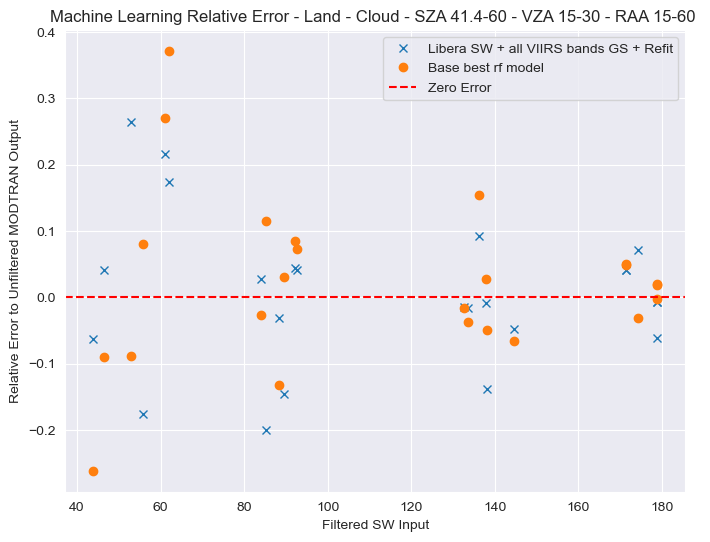

In [33]:
test_refit = test_viirs_bands_refit(all_dataset, v=True, viirs_bands=True, is_sw=True,
                                 selected_viirs_bands=['SZA', 'VZA', 'RAZ', 'Shortwave Filtered Rads (Integrated)',
                                                       'M1', 'M2','M3', 'M4', 'I1', 'M5', 'DNB', 'M6', 'I2', 'M7',
                                                       'M8', 'M9', 'I3', 'M10', 'M11', 'I4', 'M12', 'M13', 'M14',
                                                       'M15', 'I5', 'M16'],  best_params=best, use_groups=True)

test_refit_pe = calculate_pe(matt_test_data, ['SZA', 'VZA', 'RAZ', 'Shortwave Filtered Rads (Integrated)', 'M1', 'M2',
       'M3', 'M4', 'I1', 'M5', 'DNB', 'M6', 'I2', 'M7', 'M8', 'M9', 'I3',
       'M10', 'M11', 'I4', 'M12', 'M13', 'M14', 'M15', 'I5', 'M16'], test_refit['Final_Model'])

display_pe(sw_input, test_refit_pe, mtest_pe, "Libera SW + all VIIRS bands GS + Refit", "Base best rf model")

Using selected VIIRS bands: ['SZA', 'VZA', 'RAZ', 'Shortwave Filtered Rads (Integrated)', 'M1', 'M2', 'M3', 'M4', 'I1', 'M5', 'DNB', 'M6', 'I2', 'M7', 'M8', 'M9', 'I3', 'M10', 'M11']
Train (4955, 36), Val (620, 36), Test (620, 36)
Train scenes: ['Snow' 'Land' 'Deep Convective Cloud' 'Cloudy Ocean' 'Clear Ocean']
(24,) [ 0.14389454  0.03853853 -0.02000582  0.05247118  0.23269087 -0.03608221
 -0.02125771  0.05283794  0.07465194  0.11212114  0.07111108  0.05912581
 -0.07714357  0.02059085 -0.02720858  0.01819908  0.03993705 -0.12218029
 -0.13142309  0.01819682 -0.044558   -0.04532641 -0.05820493 -0.06002557]
(24,) [ 0.14389454  0.03853853 -0.02000582  0.05247118  0.23269087 -0.03608221
 -0.02125771  0.05283794  0.07465194  0.11212114  0.07111108  0.05912581
 -0.07714357  0.02059085 -0.02720858  0.01819908  0.03993705 -0.12218029
 -0.13142309  0.01819682 -0.044558   -0.04532641 -0.05820493 -0.06002557]


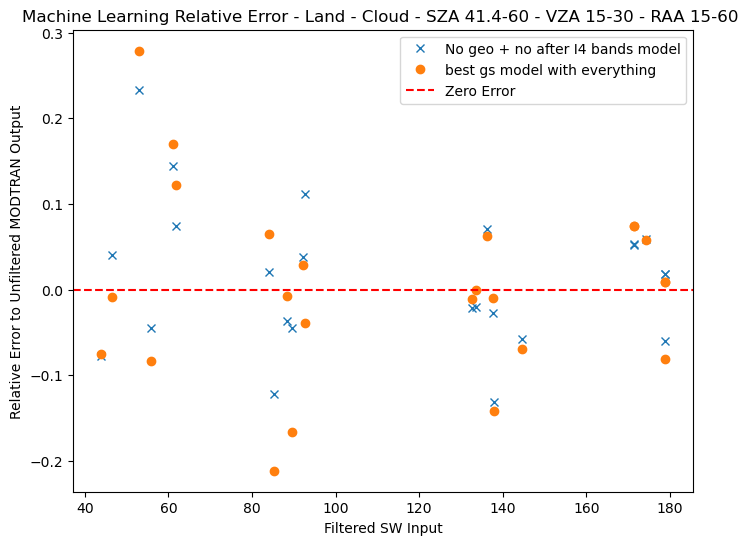

In [241]:
gs_no_geo_no_i4_refit = test_viirs_bands_refit(all_dataset, v=True, viirs_bands=True, is_sw=True,
                                 selected_viirs_bands=['SZA', 'VZA', 'RAZ','Shortwave Filtered Rads (Integrated)',
                                                       'M1', 'M2','M3', 'M4', 'I1', 'M5', 'DNB', 'M6', 'I2', 'M7',
                                                       'M8', 'M9', 'I3', 'M10', 'M11'],  best_params=best, use_groups=True)

gs_no_geo_no_i4_refit_pe = calculate_pe(matt_test_data, ['SZA', 'VZA', 'RAZ','Shortwave Filtered Rads (Integrated)',
                                        'M1', 'M2','M3', 'M4', 'I1', 'M5', 'DNB', 'M6', 'I2', 'M7',
                                        'M8', 'M9', 'I3', 'M10', 'M11'], gs_no_geo_no_i4_refit['Final_Model'])

display_pe(sw_input, gs_no_geo_no_i4_refit_pe, test_refit_pe, "No geo + no after I4 bands model", "best gs model with everything")

In [151]:
test_data = gs_no_geo_no_i4_refit["Test_data"]
X_test_data = test_data["X_test"]
y_test_data = test_data["y_test"]
drop = gs_no_geo_no_i4_refit["Drop"]
test_model = gs_no_geo_no_i4_refit["Final_Model"]
predictions = test_model.predict(X_test_data.drop(columns=drop))
X_test_data

,Scene,SZA,VZA,RAZ,Cloud,Run #,Shortwave Unfiltered Rads (Integrated),Longwave Unfiltered Rads (Integrated),Shortwave Filtered Rads (Integrated),Longwave Filtered Rads (Integrated),...,M12,M13,M14,M15,I5,M16,Scaled Shortwave Filtered,Scaled Shortwave Unfiltered,Scaled Longwave Filtered,Scaled Longwave Unfiltered
7,Snow,0.000,0.000,0.0,1,7,284.609397,65.402706,205.095865,42.506841,...,0.002900,0.000911,8.309581e-05,1.101265e-04,2.750502e-04,1.927061e-04,0.424120,0.463107,0.502001,0.487747
35,Snow,0.311,30.000,37.5,0,35,279.532816,65.430985,201.706267,42.509929,...,0.002371,0.000721,7.540319e-05,1.219162e-04,2.731814e-04,1.836364e-04,0.417029,0.454742,0.502065,0.488116
41,Snow,0.311,30.000,37.5,1,41,242.422908,66.148467,173.684409,42.888594,...,0.013730,0.005917,2.994867e-04,1.684646e-04,3.855245e-04,2.374539e-04,0.358413,0.393596,0.509945,0.497458
44,Snow,0.311,30.000,37.5,1,44,291.450253,63.268437,213.035389,41.188768,...,0.380131,0.145531,1.186496e-02,6.747721e-03,8.720603e-03,2.682703e-03,0.440727,0.474379,0.474575,0.459956
66,Snow,0.511,30.000,142.5,1,66,279.449325,61.816938,201.742337,40.219527,...,0.013729,0.005916,2.994421e-04,1.695608e-04,3.843548e-04,2.354272e-04,0.417105,0.454605,0.454407,0.441056
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6113,Clear Ocean,84.849,45.000,142.5,0,65,6.703173,92.799862,4.524054,59.390251,...,0.000391,0.000116,3.004794e-06,1.435475e-06,1.763543e-06,5.532463e-07,0.004565,0.005200,0.853313,0.844494
6126,Clear Ocean,84.852,60.000,7.5,0,78,21.651975,91.598226,15.933407,58.516188,...,0.019241,0.005467,4.837785e-05,1.229255e-05,1.415108e-05,2.987515e-06,0.028431,0.029831,0.835126,0.828847
6155,Clear Ocean,84.848,60.000,172.5,0,107,11.320198,89.326754,7.686358,57.224395,...,0.000690,0.000197,4.440745e-06,2.198739e-06,2.700902e-06,8.573936e-07,0.011180,0.012808,0.808246,0.799269
6167,Clear Ocean,85.648,89.947,37.5,0,119,27.528811,69.094287,19.949503,44.662118,...,0.000162,0.000032,2.374319e-07,1.493574e-07,1.946161e-07,7.875411e-08,0.036832,0.039515,0.546848,0.535817


In [64]:
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# Simple interactive scatter plot
fig = go.Figure()

for scene in meta_test_data["Scene"].unique():
    mask = meta_test_data["Scene"] == scene
    fig.add_trace(
        go.Scatter(
            x=y_test_data[mask],
            y=predictions[mask],
            mode='markers',
            name=scene,
            hovertemplate=
            '<b>Scene</b>: %{text}<br>' +
            '<b>True Value</b>: %{x:.2f}<br>' +
            '<b>Predicted</b>: %{y:.2f}<br>' +
            '<b>SZA</b>: %{customdata[0]:.1f}°<br>' +
            '<b>VZA</b>: %{customdata[1]:.1f}°<br>' +
            '<b>RAZ</b>: %{customdata[2]:.1f}°',
            text=[scene]*sum(mask),
            customdata=meta_test_data[mask][["SZA", "VZA", "RAZ"]],
        )
    )

# Add 1:1 line
fig.add_trace(
    go.Scatter(
        x=[min(y_test_data), max(y_test_data)],
        y=[min(y_test_data), max(y_test_data)],
        mode='lines',
        name='1:1 line',
        line=dict(color='black', dash='dash'),
    )
)

fig.update_layout(
    title="Model Predictions",
    xaxis_title="Filtered SW Radiance",
    yaxis_title="Unfiltered SW Radiance",
)

fig.show()

# Calculate R² on log-transformed data
log_y_true = np.log(y_test_data)
log_y_pred = np.log(predictions)
log_r2 = r2_score(log_y_true, log_y_pred)
mape = mean_absolute_percentage_error(y_test_data, predictions) * 100

def weighted_r2(y_true, y_pred):
    # Create bins based on magnitude
    bins = np.logspace(np.log10(min(y_true)), np.log10(max(y_true)), 10)
    bin_indices = np.digitize(y_true, bins)
    
    # Calculate weighted R² giving equal importance to each bin
    weights = 1 / np.bincount(bin_indices)[bin_indices]
    weighted_r2 = r2_score(y_true, y_pred, sample_weight=weights)
    return weighted_r2

def evaluate_by_ranges(y_true, y_pred):
    # Define magnitude ranges
    ranges = [(0, 10), (10, 100), (100, 1000)]
    
    for low, high in ranges:
        mask = (y_true >= low) & (y_true < high)
        if mask.any():
            range_r2 = r2_score(y_true[mask], y_pred[mask])
            print(f"R² for range {low}-{high}: {range_r2:.4f}")

print(f"Regular R² Value: {r2_score(y_test_data, predictions)}")
print(f"Root Mean Squared Error: {root_mean_squared_error(y_test_data, predictions)}")
print(f"Log R^2 {log_r2}")
print(f"MAPE {mape}%")
print(f"Weighted R^2 {weighted_r2(y_test_data, predictions)}")
print(f"Ranged R^2 {evaluate_by_ranges(y_test_data, predictions)}")

NameError: name 'meta_test_data' is not defined

In [152]:
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# Simple interactive scatter plot
fig = go.Figure()

for scene in X_test_data["Scene"].unique():
    mask = X_test_data["Scene"] == scene
    fig.add_trace(
        go.Scatter(
            x=y_test_data[mask],
            y=predictions[mask],
            mode='markers',
            name=scene,
            hovertemplate=
            '<b>Scene</b>: %{text}<br>' +
            '<b>True Value</b>: %{x:.2f}<br>' +
            '<b>Predicted</b>: %{y:.2f}<br>' +
            '<b>SZA</b>: %{customdata[0]:.1f}°<br>' +
            '<b>VZA</b>: %{customdata[1]:.1f}°<br>' +
            '<b>RAZ</b>: %{customdata[2]:.1f}°',
            text=[scene]*sum(mask),
            customdata=X_test_data[mask][["SZA", "VZA", "RAZ"]],
        )
    )

# Add 1:1 line
fig.add_trace(
    go.Scatter(
        x=[min(y_test_data), max(y_test_data)],
        y=[min(y_test_data), max(y_test_data)],
        mode='lines',
        name='1:1 line',
        line=dict(color='black', dash='dash'),
    )
)

fig.update_layout(
    title="Model Predictions by Scene",
    xaxis_title="True Unfiltered SW Radiance",
    yaxis_title="Predicted Unfiltered SW Radiance",
    width=800,
    height=600,
    showlegend=True,
    template="plotly_white"
)

fig.show()

# Calculate metrics
log_y_true = np.log(y_test_data)
log_y_pred = np.log(predictions)
log_r2 = r2_score(log_y_true, log_y_pred)
mape = mean_absolute_percentage_error(y_test_data, predictions) * 100

def weighted_r2(y_true, y_pred):
    bins = np.logspace(np.log10(min(y_true)), np.log10(max(y_true)), 10)
    bin_indices = np.digitize(y_true, bins)
    weights = 1 / np.bincount(bin_indices)[bin_indices]
    weighted_r2 = r2_score(y_true, y_pred, sample_weight=weights)
    return weighted_r2

def evaluate_by_ranges(y_true, y_pred):
    ranges = [(0, 10), (10, 100), (100, 1000)]
    results = {}
    for low, high in ranges:
        mask = (y_true >= low) & (y_true < high)
        if mask.any():
            range_r2 = r2_score(y_true[mask], y_pred[mask])
            print(f"R² for range {low}-{high}: {range_r2:.4f}")
            results[f"{low}-{high}"] = range_r2
    return results

# Print all metrics
print("\nModel Performance Metrics:")
print("--------------------------")
print(f"Regular R² Value: {r2_score(y_test_data, predictions):.4f}")
print(f"Root Mean Squared Error: {root_mean_squared_error(y_test_data, predictions):.4f}")
print(f"Log R² Value: {log_r2:.4f}")
print(f"Mean Absolute Percentage Error: {mape:.2f}%")
print(f"Weighted R² Value: {weighted_r2(y_test_data, predictions):.4f}")
print("\nR² Values by Range:")
print("--------------------------")
evaluate_by_ranges(y_test_data, predictions)


Model Performance Metrics:
--------------------------
Regular R² Value: 0.9999
Root Mean Squared Error: 0.9884
Log R² Value: 0.9999
Mean Absolute Percentage Error: 0.56%
Weighted R² Value: 0.9999

R² Values by Range:
--------------------------
R² for range 0-10: 0.9908
R² for range 10-100: 0.9997
R² for range 100-1000: 0.9997


{'0-10': 0.9908184563162336,
 '10-100': 0.9996554873669488,
 '100-1000': 0.999747420547181}

In [67]:
all_dataset[all_dataset["SZA"] == 95.0]

,Scene,SZA,VZA,RAZ,Cloud,Run #,Shortwave Unfiltered Rads (Integrated),Longwave Unfiltered Rads (Integrated),Shortwave Filtered Rads (Integrated),Longwave Filtered Rads (Integrated),...,M12,M13,M14,M15,I5,M16,Scaled Shortwave Filtered,Scaled Shortwave Unfiltered,Scaled Longwave Filtered,Scaled Longwave Unfiltered
480,Land,95.0,79.914,7.5,0,480,168.115013,68.801520,129.332746,44.499381,...,0.076379,0.009038,0.000171,0.000223,0.000271,0.000100,0.265639,0.271159,0.543462,0.532004
481,Land,95.0,79.914,7.5,1,481,550.342487,56.715972,432.004821,37.060982,...,0.961519,0.176285,0.025862,0.047027,0.095099,0.068558,0.898766,0.900956,0.388683,0.374635
482,Land,95.0,79.914,7.5,1,482,574.645778,53.792381,451.196905,35.206914,...,0.985401,0.207783,0.027777,0.045270,0.093940,0.067284,0.938912,0.941001,0.350103,0.336566
483,Land,95.0,79.914,7.5,1,483,158.091881,68.775704,121.270149,44.489129,...,0.065295,0.007916,0.000171,0.000224,0.000271,0.000100,0.248774,0.254644,0.543249,0.531668
484,Land,95.0,79.914,7.5,1,484,125.260098,67.946926,95.246643,43.996333,...,0.048640,0.006486,0.000785,0.001527,0.001848,0.000688,0.194338,0.200547,0.532995,0.520876
485,Land,95.0,79.914,7.5,0,485,168.074588,68.793082,129.299371,44.496562,...,0.076351,0.009035,0.000171,0.000223,0.000271,0.000100,0.265569,0.271092,0.543404,0.531894
486,Land,95.0,79.914,7.5,1,486,550.342487,56.713280,432.004821,37.059425,...,0.961519,0.176285,0.025862,0.047027,0.095099,0.068558,0.898766,0.900956,0.388651,0.374600
487,Land,95.0,79.914,7.5,1,487,574.645778,53.792378,451.196905,35.206914,...,0.985401,0.207783,0.027777,0.045270,0.093940,0.067284,0.938912,0.941001,0.350103,0.336566
488,Land,95.0,79.914,7.5,1,488,158.091881,68.775483,121.270149,44.489097,...,0.065295,0.007916,0.000171,0.000224,0.000271,0.000100,0.248774,0.254644,0.543248,0.531665
489,Land,95.0,79.914,7.5,1,489,125.260098,67.946926,95.246643,43.996333,...,0.048640,0.006486,0.000785,0.001527,0.001848,0.000688,0.194338,0.200547,0.532995,0.520876


In [6]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression

land_all = all_dataset[all_dataset["Scene"] == "Land"].copy()

unfilt_sw = land_all['Shortwave Unfiltered Rads (Integrated)'].to_numpy()
filt_sw = land_all['Shortwave Filtered Rads (Integrated)'].to_numpy()

print(np.shape(unfilt_sw), np.shape(filt_sw))

input = filt_sw.reshape(-1, 1)
output = unfilt_sw.reshape(-1, 1)

print(np.shape(input), np.shape(output))

poly_model = PolynomialFeatures(degree=1)
poly_x = poly_model.fit_transform(input)

poly_model.fit(poly_x, output)

regression = LinearRegression()
regression.fit(poly_x, output)

predicted = regression.predict(poly_x)
print(f"r^2 Value: {r2_score(unfilt_sw, predicted)}")
print(f"Mean Squared Error: {mean_squared_error(unfilt_sw, predicted)}")

mv_relative_error = (unfilt_sw-predicted)/unfilt_sw*100

(3150,) (3150,)
(3150, 1) (3150, 1)
r^2 Value: 0.9989333055572432
Mean Squared Error: 7.385438955736645


In [4]:
subset = land_all[(land_all["SZA"].between(40,60)) &
                  (land_all["VZA"].between(15,30)) &
                  (land_all["RAZ"].between(15,60))]

filt_sw_bin = subset['Shortwave Filtered Rads (Integrated)'].to_numpy()
unfilt_sw_bin = subset['Shortwave Unfiltered Rads (Integrated)'].to_numpy()

input_bin = filt_sw_bin.reshape(-1, 1)
output_bin = unfilt_sw_bin.reshape(-1, 1)

print(np.shape(input_bin), np.shape(output_bin))

poly_model_bin = PolynomialFeatures(degree=1)
poly_x_bin = poly_model_bin.fit_transform(input_bin)

poly_model_bin.fit(poly_x_bin, output_bin)

regression_bin = LinearRegression()
regression_bin.fit(poly_x_bin, output_bin)

predicted_bin = regression_bin.predict(poly_x_bin)
print(f"r^2 Value: {r2_score(unfilt_sw_bin, predicted_bin)}")
print(f"Mean Squared Error: {mean_squared_error(unfilt_sw_bin, predicted_bin)}")

mv_relative_error_bin = (unfilt_sw_bin-predicted_bin)/unfilt_sw_bin*100

(30, 1) (30, 1)
r^2 Value: 0.9999108521471843
Mean Squared Error: 0.43130662368247114


For all Land Clear data:
r^2 Value: 0.9989574378065708
Mean Squared Error: 7.218355255729035

For binned Land Clear data:
r^2 Value: 0.9999108521471843
Mean Squared Error: 0.43130662368247114


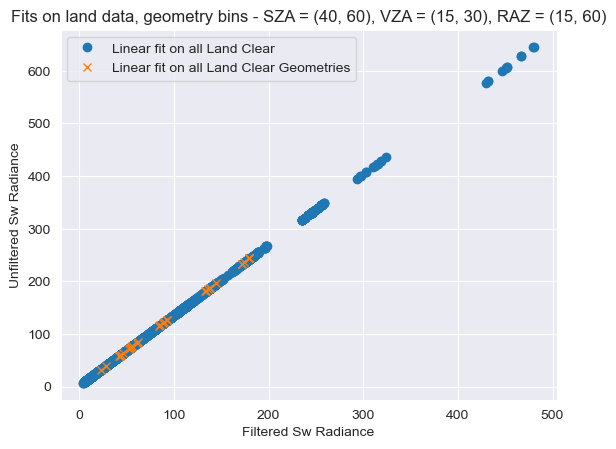

In [5]:
plt.plot(filt_sw, predicted, "o", label="Linear fit on all Land Clear")
plt.plot(filt_sw_bin, predicted_bin, "x", label="Linear fit on all Land Clear Geometries")
plt.title("Fits on land data, geometry bins - SZA = (40, 60), VZA = (15, 30), RAZ = (15, 60)")
plt.xlabel("Filtered Sw Radiance")
plt.ylabel("Unfiltered Sw Radiance")
plt.legend()


print("For all Land Clear data:")
print(f"r^2 Value: {r2_score(unfilt_sw, predicted)}")
print(f"Mean Squared Error: {mean_squared_error(unfilt_sw, predicted)}")
print("\nFor binned Land Clear data:")
print(f"r^2 Value: {r2_score(unfilt_sw_bin, predicted_bin)}")
print(f"Mean Squared Error: {mean_squared_error(unfilt_sw_bin, predicted_bin)}")

For all Land Clear data:
R² Value: 0.9989333055572432
Root Mean Squared Error: 2.7176164107056473
coefficients: [[0.         1.33836912]], intercept: [1.89962049]

For binned Land Clear data:
R² Value: 0.9999086722226891
Root Mean Squared Error: 0.6339710917547905
coefficients: [[0.         1.35340604]], intercept: [1.09064957]


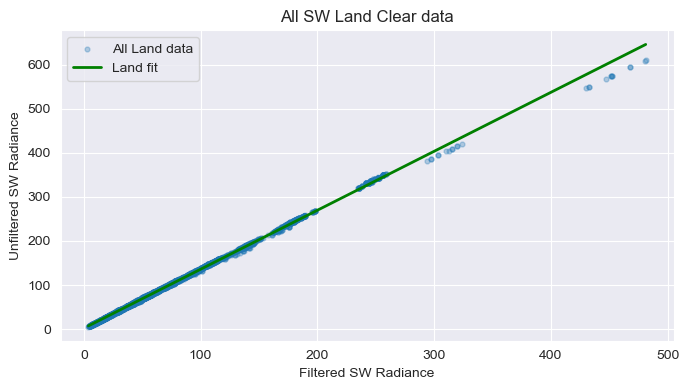

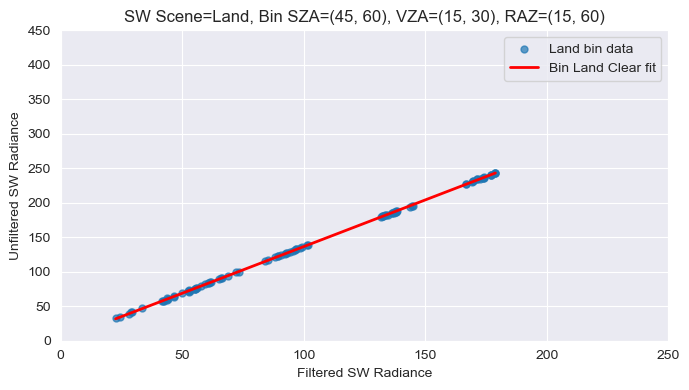

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression

def compare_global_vs_bin_fit(df, scene="Land", sza_range=(45,60), vza_range=(15,30), raz_range=(15,60), degree=1, is_sw=True):
    """
    Compare global linear/poly fit vs a single geometry-bin fit.
    Plots both fits together.

    Args:
        df: DataFrame with 'Scene','SZA','VZA','RAZ', SW filtered/unfiltered columns.
        scene: which Scene to filter to.
        *_range: tuple of (low, high) to select bin for SZA,VZA,RAZ.
        degree: polynomial degree (1=linear, 2=quadratic).
    """
    if is_sw:
        filt_col = "Shortwave Filtered Rads (Integrated)"
        unfilt_col = "Shortwave Unfiltered Rads (Integrated)"
    else:
        filt_col = "Longwave Filtered Rads (Integrated)"
        unfilt_col = "Longwave Unfiltered Rads (Integrated)"

    # ---- GLOBAL FIT ----
    land = df[df["Scene"] == scene]
    X_global = land[[filt_col]].to_numpy().reshape(-1, 1)  # just filtered radiance
    y_global = land[unfilt_col].to_numpy().reshape(-1, 1)

    poly = PolynomialFeatures(degree=degree)
    Xg_poly = poly.fit_transform(X_global)
    g_model = LinearRegression().fit(Xg_poly, y_global)

    # ---- BIN FIT ----
    # subset = land[
    #     land["SZA"].between(*sza_range) &
    #     land["VZA"].between(*vza_range) &
    #     land["RAZ"].between(*raz_range)
    # ]
    subset = land[(land["SZA"].between(40,60)) &
                  (land["VZA"].between(15,60)) &
                  (land["RAZ"].between(15,60))]

    X_bin = subset[filt_col].to_numpy().reshape(-1, 1)
    y_bin = subset[unfilt_col].to_numpy().reshape(-1, 1)

    Xb_poly = poly.fit_transform(X_bin)
    b_model = LinearRegression().fit(Xb_poly, y_bin)

    # Get R² and RMSE for both models
    g_pred = g_model.predict(Xg_poly)
    b_pred = b_model.predict(Xb_poly)

    # Print metrics and coefficients
    print("For all Land Clear data:")
    print(f"R² Value: {r2_score(y_global, g_pred)}")
    print(f"Root Mean Squared Error: {root_mean_squared_error(y_global, g_pred)}")
    print(f"coefficients: {g_model.coef_}, intercept: {g_model.intercept_}")


    print("\nFor binned Land Clear data:")
    print(f"R² Value: {r2_score(y_bin, b_pred)}")
    print(f"Root Mean Squared Error: {root_mean_squared_error(y_bin, b_pred)}")
    print(f"coefficients: {b_model.coef_}, intercept: {b_model.intercept_}")


    x_line = np.linspace(min(X_global.min(), X_bin.min()),
                         max(X_global.max(), X_bin.max()), 200).reshape(-1,1)
    x_line_poly = poly.transform(x_line)

    plt.figure(figsize=(7,4))
    # scatter the data
    plt.scatter(X_global, y_global, s=12, alpha=0.3, label="All Land data")
    idx_g = np.argsort(X_global.ravel())
    plt.plot(X_global[idx_g], g_model.predict(Xg_poly)[idx_g],
             color="green", lw=2, label=f"{scene} fit")

    temp = "SW" if is_sw else "LW"
    plt.xlabel(f"Filtered {temp} Radiance")
    plt.ylabel(f"Unfiltered {temp} Radiance")
    plt.title(f"All {temp} Land Clear data")
    plt.legend()
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(7,4))
    plt.scatter(X_bin, y_bin, s=25, alpha=0.7, label=f"{scene} bin data")
    # plt.scatter(X_global, y_global, s=12, alpha=0.3, label="All Land data")
    idx_b = np.argsort(X_bin.ravel())
    # plt.plot(X_global[idx_g], g_model.predict(Xg_poly)[idx_g],
    #          color="green", lw=2, label="All Land Clear fit")
    plt.plot(X_bin[idx_b], b_model.predict(Xb_poly)[idx_b],
             color="red", lw=2, label="Bin Land Clear fit")

    plt.xlabel(f"Filtered {temp} Radiance")
    plt.ylabel(f"Unfiltered {temp} Radiance")
    plt.xlim(0, 250)
    plt.ylim(0, 450)
    plt.title(f"{temp} Scene={scene}, Bin SZA={sza_range}, VZA={vza_range}, RAZ={raz_range}")
    plt.legend()
    plt.tight_layout()
    plt.show()


compare_global_vs_bin_fit(
    land_all,
    scene="Land",
    sza_range=(45,60),
    vza_range=(15,30),
    raz_range=(15,60),
    degree=1  # linear, or 2 for quadratic
)

In [55]:
all_dataset["Shortwave Unfiltered Rads (Integrated)"].min(), all_dataset["Shortwave Unfiltered Rads (Integrated)"].max()

(3.5472382110609804, 610.4526726464998)

In [ ]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots

def compare_global_vs_bin_fit_interactive(df, scene="Land", sza_range=(45,60), vza_range=(15,30), raz_range=(15,60), degree=1, ml_model=None):
    """
    Compare global linear/poly fit vs a single geometry-bin fit with interactive plots.
    """
    filt_col = "Shortwave Filtered Rads (Integrated)"
    unfilt_col = "Shortwave Unfiltered Rads (Integrated)"

    # ---- GLOBAL FIT ----
    land = df[df["Scene"] == scene]
    X_global = land[[filt_col]].to_numpy().reshape(-1, 1)
    y_global = land[unfilt_col].to_numpy().reshape(-1, 1)

    poly = PolynomialFeatures(degree=degree)
    Xg_poly = poly.fit_transform(X_global)
    g_model = LinearRegression().fit(Xg_poly, y_global)

    # ---- BIN FIT ----
    subset = land[(land["SZA"].between(40,60)) &
                  (land["VZA"].between(15,60)) &
                  (land["RAZ"].between(15,60))]

    X_bin = subset[filt_col].to_numpy().reshape(-1, 1)
    y_bin = subset[unfilt_col].to_numpy().reshape(-1, 1)

    Xb_poly = poly.fit_transform(X_bin)
    b_model = LinearRegression().fit(Xb_poly, y_bin)

    # Get predictions
    g_pred = g_model.predict(Xg_poly)
    b_pred = b_model.predict(Xb_poly)
    # add model predictions
    # m_pred = ml_model.predict()

    # Print metrics and coefficients
    print("For all Land Clear data:")
    print(f"R² Value: {r2_score(y_global, g_pred)}")
    print(f"Root Mean Squared Error: {root_mean_squared_error(y_global, g_pred)}")
    print(f"coefficients: {g_model.coef_}, intercept: {g_model.intercept_}")

    print("\nFor binned Land Clear data:")
    print(f"R² Value: {r2_score(y_bin, b_pred)}")
    print(f"Root Mean Squared Error: {root_mean_squared_error(y_bin, b_pred)}")
    print(f"coefficients: {b_model.coef_}, intercept: {b_model.intercept_}")

    # do model metrics as well to print out

    # Create two subplots
    # TODO add subplots for each of the ml model predictions
    fig = make_subplots(rows=1, cols=2, 
                       subplot_titles=(f"All {scene} Data", 
                                     f"{scene} Data (SZA={sza_range}, VZA={vza_range}, RAZ={raz_range})"))

    # Plot 1: Global fit
    fig.add_trace(
        go.Scatter(
            x=X_global.ravel(),
            y=y_global.ravel(),
            mode='markers',
            name='All data points',
            marker=dict(size=6, opacity=0.5),
            hovertemplate="<br>".join([
                "Filtered SW: %{x:.2f}",
                "Unfiltered SW: %{y:.2f}",
            ]),
        ),
        row=1, col=1
    )

    # Add global fit line
    idx_g = np.argsort(X_global.ravel())
    fig.add_trace(
        go.Scatter(
            x=X_global.ravel()[idx_g],
            y=g_pred.ravel()[idx_g],
            mode='lines',
            name=f'{scene} global fit',
            line=dict(color='green', width=2),
        ),
        row=1, col=1
    )

    # Plot 2: Binned fit
    fig.add_trace(
        go.Scatter(
            x=X_bin.ravel(),
            y=y_bin.ravel(),
            mode='markers',
            name='Binned data points',
            marker=dict(size=8),
            hovertemplate="<br>".join([
                "Filtered SW: %{x:.2f}",
                "Unfiltered SW: %{y:.2f}",
            ]),
        ),
        row=1, col=2
    )

    # Add binned fit line
    idx_b = np.argsort(X_bin.ravel())
    fig.add_trace(
        go.Scatter(
            x=X_bin.ravel()[idx_b],
            y=b_pred.ravel()[idx_b],
            mode='lines',
            name='Binned fit',
            line=dict(color='red', width=2),
        ),
        row=1, col=2
    )

    # Update layout
    fig.update_layout(
        height=500,
        width=1200,
        showlegend=True,
        title_text=f"Linear Fits for {scene} Scene",
    )

    # Update axes
    # Example of manual ranges
    fig.update_xaxes(title_text="Filtered SW Radiance", range=[0, 500], row=1, col=1)
    fig.update_yaxes(title_text="Unfiltered SW Radiance", range=[0, 700], row=1, col=1)

    fig.update_xaxes(title_text="Filtered SW Radiance", range=[0, 200], row=1, col=2)
    fig.update_yaxes(title_text="Unfiltered SW Radiance", range=[0, 300], row=1, col=2)

    fig.show()

# Call the function with your data
compare_global_vs_bin_fit_interactive(
    land_all,
    scene="Land",
    sza_range=(45,60),
    vza_range=(15,30),
    raz_range=(15,60),
    degree=1
)

For all Land Clear data:
R² Value: 0.9989574378065708
Root Mean Squared Error: 2.6866996958590357
coefficients: [[0.         1.33924749]], intercept: [1.87468988]

For binned Land Clear data:
R² Value: 0.9999159354889353
Root Mean Squared Error: 0.6082391305827173
coefficients: [[0.         1.35417569]], intercept: [1.07661543]


In [77]:
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots


def compare_global_vs_bin_fit_interactive(df, scene="Land", sza_range=(45,60), vza_range=(15,30),
                                        raz_range=(15,60), degree=1, ml_model=None, name=None, ml_features=None, is_sw=True):
    """
    Compare global linear/poly fit vs a single geometry-bin fit with interactive plots.
    If ml_model is provided, also plots its predictions.
    """
    if is_sw:
        filt_col = "Shortwave Filtered Rads (Integrated)"
        unfilt_col = "Shortwave Unfiltered Rads (Integrated)"
        temp = "SW"
    else:
        filt_col = "Longwave Filtered Rads (Integrated)"
        unfilt_col = "Longwave Unfiltered Rads (Integrated)"
        temp = "LW"

    # ---- GLOBAL FIT ----
    # land = df[df["Scene"] == scene]
    land = df
    X_global = land[[filt_col]].to_numpy().reshape(-1, 1)
    y_global = land[unfilt_col].to_numpy().reshape(-1, 1)

    poly = PolynomialFeatures(degree=degree)
    Xg_poly = poly.fit_transform(X_global)
    g_model = LinearRegression().fit(Xg_poly, y_global)

    # ---- BIN FIT ----
    subset = land[(land["SZA"].between(40,60)) &
                  (land["VZA"].between(15,60)) &
                  (land["RAZ"].between(15,60))]

    X_bin = subset[filt_col].to_numpy().reshape(-1, 1)
    y_bin = subset[unfilt_col].to_numpy().reshape(-1, 1)

    Xb_poly = poly.fit_transform(X_bin)
    b_model = LinearRegression().fit(Xb_poly, y_bin)

    # Get predictions
    g_pred = g_model.predict(Xg_poly)
    b_pred = b_model.predict(Xb_poly)

    # Create layout based on whether ML model is provided
    n_cols = 2 if ml_model is not None else 2
    fig = make_subplots(rows=2, cols=n_cols,
                       subplot_titles=(f"{name}",
                                     f"{name} Data (SZA={sza_range}, VZA={vza_range}, RAZ={raz_range})",
                                     f"ML Predictions for {name} (unbinned)" if ml_model else None, f"ML for {name} (binned)" if ml_model else None))

    # Plot 1: Global fit
    fig.add_trace(
        go.Scatter(
            x=X_global.ravel(),
            y=y_global.ravel(),
            mode='markers',
            name='Land data points',
            marker=dict(size=6, opacity=0.5),
            hovertemplate="<br>".join([
                "Filtered: %{x:.2f}",
                "Unfiltered: %{y:.2f}",
            ]),
        ),
        row=1, col=1
    )

    idx_g = np.argsort(X_global.ravel())
    fig.add_trace(
        go.Scatter(
            x=X_global.ravel()[idx_g],
            y=g_pred.ravel()[idx_g],
            mode='lines',
            name=f'{scene} global fit',
            line=dict(color='green', width=2),
        ),
        row=1, col=1
    )

    # Plot 2: Binned fit
    fig.add_trace(
        go.Scatter(
            x=X_bin.ravel(),
            y=y_bin.ravel(),
            mode='markers',
            name='Land Binned data points',
            marker=dict(size=8),
            hovertemplate="<br>".join([
                "Filtered: %{x:.2f}",
                "Unfiltered: %{y:.2f}",
            ]),
        ),
        row=1, col=2
    )

    idx_b = np.argsort(X_bin.ravel())
    fig.add_trace(
        go.Scatter(
            x=X_bin.ravel()[idx_b],
            y=b_pred.ravel()[idx_b],
            mode='lines',
            name='Binned fit',
            line=dict(color='red', width=2),
        ),
        row=1, col=2
    )

    # Plot 3: ML model predictions (if provided)
    ml_pred = None
    reg_model = None
    if ml_model is not None:
        # Get ML model features
        # ml_features = ['SZA','VZA', 'RAZ', 'Shortwave Filtered Rads (Integrated)', 'M1', 'M2', 'M3', 'M4', 'I1', 'M5', 'DNB', 'M6', 'I2', 'M7', 'M8', 'M9', 'I3', 'M10', 'M11']
        # if hasattr(ml_model, 'feature_names_in_'):
        #     ml_features = ml_model.feature_names_in_

        X_ml = land[ml_features].to_numpy()
        X_bin_ml = subset[ml_features].to_numpy()
        ml_pred = ml_model.predict(X_ml)
        ml_pred_bin = ml_model.predict(X_bin_ml)


        # # True values scatter
        # fig.add_trace(
        #     go.Scatter(
        #         x=X_global.ravel(),
        #         y=y_global.ravel(),
        #         mode='markers',
        #         name='True values',
        #         marker=dict(size=6, color="black"),
        #         hovertemplate="<br>".join([
        #             "Filtered SW: %{x:.2f}",
        #             "True Unfiltered: %{y:.2f}",
        #         ]),
        #     ),
        #     row=2, col=1
        # )

        # ML predictions scatter
        fig.add_trace(
            go.Scatter(
                x=y_global.ravel(),
                y=ml_pred,
                mode='markers',
                name='ML predictions',
                marker=dict(size=6, color='red'),
                hovertemplate="<br>".join([
                    "Unfiltered: %{x:.2f}",
                    "Predicted: %{y:.2f}",
                ]),
            ),
            row=2, col=1
        )


        fig.add_trace(
            go.Scatter(
                x=y_bin.ravel(),
                y=ml_pred_bin,
                mode='markers',
                name='ML predictions',
                marker=dict(size=6, color='red'),
                hovertemplate="<br>".join([
                    "Unfiltered: %{x:.2f}",
                    "Predicted: %{y:.2f}",
                ]),
            ),
            row=2, col=2
        )

        # Add regression line for ML predictions
        idx_ml = np.argsort(y_global.ravel())
        poly_ml = PolynomialFeatures(degree=1)
        X_line = y_global.ravel()[idx_ml].reshape(-1, 1)
        y_line = ml_pred[idx_ml].reshape(-1, 1)
        reg_model = LinearRegression().fit(poly_ml.fit_transform(X_line), y_line)
        line_pred = reg_model.predict(poly_ml.transform(X_line))

        idx_ml_bin = np.argsort(y_bin.ravel())
        poly_ml_bin = PolynomialFeatures(degree=1)
        X_line_bin = y_bin.ravel()[idx_ml_bin].reshape(-1, 1)
        y_line_bin = ml_pred_bin[idx_ml_bin].reshape(-1, 1)
        reg_model_bin = LinearRegression().fit(poly_ml_bin.fit_transform(X_line_bin), y_line_bin)
        line_pred_bin = reg_model_bin.predict(poly_ml.transform(X_line_bin))

        fig.add_trace(
            go.Scatter(
                x=X_line.ravel(),
                y=line_pred.ravel(),
                mode='lines',
                name='ML regression line',
                line=dict(color='blue', width=2, dash='dash'),
            ),
            row=2, col=1
        )

        fig.add_trace(
            go.Scatter(
                x=X_line_bin.ravel(),
                y=line_pred_bin.ravel(),
                mode='lines',
                name='ML regression line',
                line=dict(color='blue', width=2, dash='dash'),
            ),
            row=2, col=2
        )
        # for col, (X_data, y_pred_data) in enumerate([(X_global, ml_pred), (X_bin, ml_pred_bin)], 1):
        #     idx_sort = np.argsort(X_data.ravel())
        #     X_line = X_data.ravel()[idx_sort].reshape(-1, 1)
        #     y_line = y_pred_data[idx_sort].reshape(-1, 1)

        #     poly_ml = PolynomialFeatures(degree=1)
        #     reg_model = LinearRegression().fit(poly_ml.fit_transform(X_line), y_line)
        #     line_pred = reg_model.predict(poly_ml.transform(X_line))

        #     fig.add_trace(
        #         go.Scatter(
        #             x=X_line.ravel(),
        #             y=line_pred.ravel(),
        #             mode='lines',
        #             name=f'ML regression line {"(binned)" if col==2 else ""}',
        #             line=dict(color='purple', width=2, dash='dash'),
        #         ),
        #         row=2, col=col
        #     )


    # Update layout
    fig.update_layout(
        height=800,
        width=400 * 3,
        showlegend=True,
        title_text=f"Model Comparisons for {scene} Scene",
    )

    # Update axes for all subplots
    for i in range(1, n_cols + 1):
        fig.update_xaxes(title_text=f"Filtered {temp} Radiance", row=1, col=i)
        fig.update_yaxes(title_text=f"Unfiltered {temp} Radiance", row=1, col=i)
    for i in range(1, n_cols + 1):
        fig.update_xaxes(title_text=f"Unfiltered {temp} Radiance", row=2, col=i)
        fig.update_yaxes(title_text=f"Unfiltered MODEL PREDICTIONS {temp} Radiance", row=2, col=i)

    fig.show()

    # Print metrics for linear models
    print("\nFor all Land Clear data:")
    print(f"R² Value: {r2_score(y_global, g_pred)}")
    print(f"Root Mean Squared Error: {root_mean_squared_error(y_global, g_pred)}")
    print(f"coefficients: {g_model.coef_}, intercept: {g_model.intercept_}")

    print("\nFor binned Land Clear data:")
    print(f"R² Value: {r2_score(y_bin, b_pred)}")
    print(f"Root Mean Squared Error: {root_mean_squared_error(y_bin, b_pred)}")
    print(f"coefficients: {b_model.coef_}, intercept: {b_model.intercept_}")

    if ml_pred is not None:
        # Print ML model metrics
        print("\nML Model Metrics:")
        print(f"R² Value: {r2_score(y_global, ml_pred)}")
        print(f"Root Mean Squared Error: {root_mean_squared_error(y_global, ml_pred)}")
        print(f"Mean Absolute Percentage Error: {mean_absolute_percentage_error(y_global, ml_pred)*100:.2f}%")
        print(f"Regression line coefficients: {reg_model.coef_}, intercept: {reg_model.intercept_}")

In [217]:
compare_global_vs_bin_fit_interactive(
    land_all,
    scene="Land",
    sza_range=(45,60),
    vza_range=(15,30),
    raz_range=(15,60),
    degree=1,
    ml_model=test_model,
    name="All Land"
)


For all Land Clear data:
R² Value: 0.9989574378065708
Root Mean Squared Error: 2.6866996958590357
coefficients: [[0.         1.33924749]], intercept: [1.87468988]

For binned Land Clear data:
R² Value: 0.9999159354889353
Root Mean Squared Error: 0.6082391305827173
coefficients: [[0.         1.35417569]], intercept: [1.07661543]

ML Model Metrics:
R² Value: 0.9999774631576342
Root Mean Squared Error: 0.3950159879263969
Mean Absolute Percentage Error: 0.19%
Regression line coefficients: [[0.         1.33931729]], intercept: [1.87243578]


In [61]:
land_clear = land_all[land_all["Cloud"] == 0]
land_cloudy = land_all[land_all["Cloud"] == 1]

In [212]:
land_clear["SZA"].unique(), land_clear["VZA"].unique(), land_clear["RAZ"].unique()

(array([ 0.   ,  0.506,  0.405,  0.871,  0.697,  1.487,  1.19 , 10.   ,
         8.002, 41.4  , 41.906, 41.805, 40.995, 40.894, 42.271, 42.097,
        40.703, 40.529, 42.887, 42.59 , 40.21 , 39.913, 51.4  , 49.402,
        33.398, 31.4  , 60.   , 60.506, 60.405, 59.595, 59.494, 60.871,
        60.697, 59.303, 59.129, 61.487, 61.19 , 58.81 , 58.513, 70.   ,
        68.002, 51.998, 50.   , 75.   , 75.506, 75.405, 74.595, 74.494,
        75.871, 75.697, 74.303, 74.129, 76.487, 76.19 , 73.81 , 73.513,
        85.   , 83.002, 66.998, 65.   , 85.506, 85.405, 84.595, 84.494,
        85.871, 85.697, 84.303, 84.129, 86.487, 86.19 , 83.81 , 83.513,
        95.   , 93.002, 76.998]),
 array([ 0.     , 29.49001, 44.121  , 58.5    , 79.914  ]),
 array([  0. ,   7.5,  37.5,  90. , 142.5, 172.5]))

In [213]:
land_cloudy["SZA"].unique(), land_cloudy["VZA"].unique(), land_cloudy["RAZ"].unique()

(array([ 0.   ,  0.506,  0.405,  0.871,  0.697,  1.487,  1.19 , 10.   ,
         8.002, 41.4  , 41.906, 41.805, 40.995, 40.894, 42.271, 42.097,
        40.703, 40.529, 42.887, 42.59 , 40.21 , 39.913, 51.4  , 49.402,
        33.398, 31.4  , 60.   , 60.506, 60.405, 59.595, 59.494, 60.871,
        60.697, 59.303, 59.129, 61.487, 61.19 , 58.81 , 58.513, 70.   ,
        68.002, 51.998, 50.   , 75.   , 75.506, 75.405, 74.595, 74.494,
        75.871, 75.697, 74.303, 74.129, 76.487, 76.19 , 73.81 , 73.513,
        85.   , 83.002, 66.998, 65.   , 85.506, 85.405, 84.595, 84.494,
        85.871, 85.697, 84.303, 84.129, 86.487, 86.19 , 83.81 , 83.513,
        95.   , 93.002, 76.998]),
 array([ 0.     , 29.49001, 44.121  , 58.5    , 79.914  ]),
 array([  0. ,   7.5,  37.5,  90. , 142.5, 172.5]))

In [214]:
compare_global_vs_bin_fit_interactive(
    land_clear,
    scene="Land",
    sza_range=(45,60),
    vza_range=(15,30),
    raz_range=(15,60),
    degree=1,
    ml_model=test_model,
    name="Land Clear"
)


For all Land Clear data:
R² Value: 0.998586330255098
Root Mean Squared Error: 1.3378094390555044
coefficients: [[0.         1.33029349]], intercept: [1.8294728]

For binned Land Clear data:
R² Value: 0.9990947501499154
Root Mean Squared Error: 0.4377100010776031
coefficients: [[0.         1.29506035]], intercept: [3.24734218]

ML Model Metrics:
R² Value: 0.9998989553049612
Root Mean Squared Error: 0.3576654853866518
Mean Absolute Percentage Error: 0.40%
Regression line coefficients: [[0.         1.33382887]], intercept: [1.6931163]


In [208]:
compare_global_vs_bin_fit_interactive(
    land_cloudy,
    scene="Land",
    sza_range=(45,60),
    vza_range=(15,30),
    raz_range=(15,60),
    degree=1,
    ml_model=test_model,
    name="Land Cloudy"
)


For all Land Clear data:
R² Value: 0.9988693062780992
Root Mean Squared Error: 2.9173050213773744
coefficients: [[0.         1.33852318]], intercept: [2.03532587]

For binned Land Clear data:
R² Value: 0.9999222890252646
Root Mean Squared Error: 0.5160969892563709
coefficients: [[0.         1.35211162]], intercept: [1.39338561]

ML Model Metrics:
R² Value: 0.9999783357118746
Root Mean Squared Error: 0.4038141757511949
Mean Absolute Percentage Error: 0.14%
Regression line coefficients: [[0.         1.33844715]], intercept: [2.04547215]


For all Land Clear data:
R² Value: 0.9974037887070017
Root Mean Squared Error: 1.68172578055097
coefficients: [[0.         1.31993824]], intercept: [2.94511157]

For binned Land Clear data:
R² Value: 0.9985851527184804
Root Mean Squared Error: 0.42043667590099615
coefficients: [[0.         1.36160246]], intercept: [2.45929505]


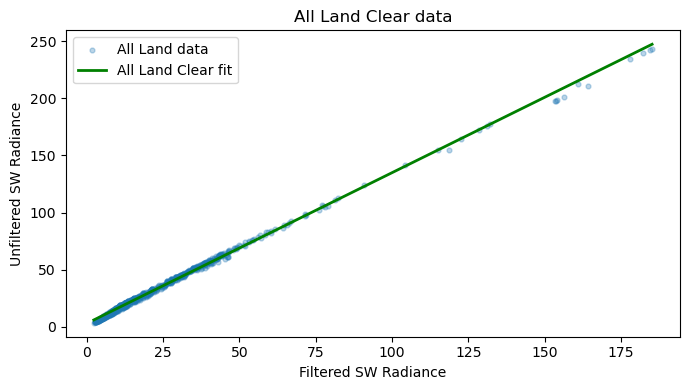

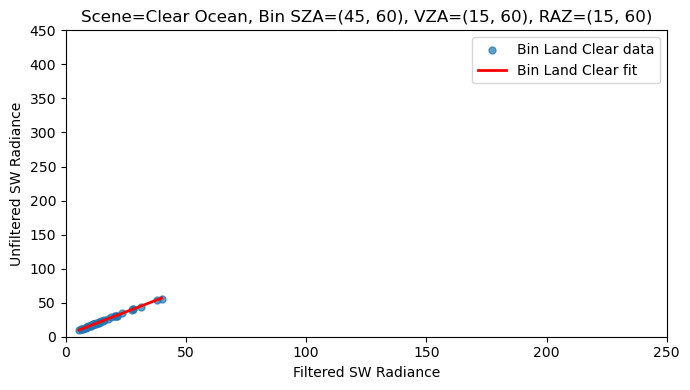

In [38]:
compare_global_vs_bin_fit(
    clear_dataset,
    scene="Clear Ocean",
    sza_range=(45,60),
    vza_range=(15,60),
    raz_range=(15,60),
    degree=1  # linear, or 2 for quadratic
)

For all Land Clear data:
R² Value: 0.9987406490881646
Root Mean Squared Error: 3.0100462045404197
coefficients: [[0.         1.34140077]], intercept: [2.21510996]

For binned Land Clear data:
R² Value: 0.9999141418818412
Root Mean Squared Error: 0.5031122795494272
coefficients: [[0.         1.35769652]], intercept: [1.24146224]


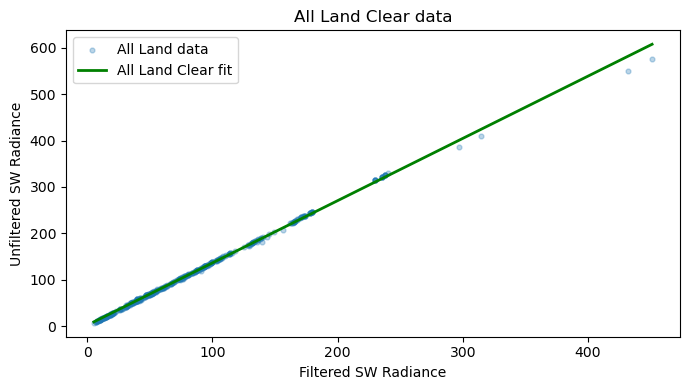

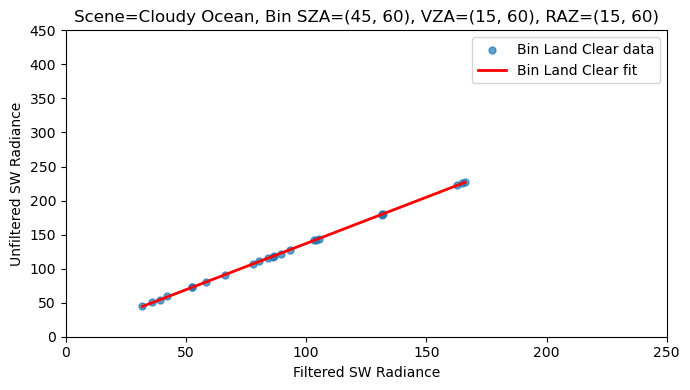

In [43]:
compare_global_vs_bin_fit(
    cloud_dataset,
    scene="Cloudy Ocean",
    sza_range=(45,60),
    vza_range=(15,60),
    raz_range=(15,60),
    degree=1  # linear, or 2 for quadratic
)

In [113]:
target_col = "Shortwave Unfiltered Rads (Integrated)" 
filtered_sw = "Shortwave Filtered Rads (Integrated)"
filtered_lw = "Longwave Filtered Rads (Integrated)"

# Base columns to drop from X (do NOT include the target here)
columns_to_drop = [
    "Run #", "Scene", "Shortwave Unfiltered Rads (Integrated)",
    "Longwave Unfiltered Rads (Integrated)", filtered_lw,
    "Scaled Longwave Unfiltered", "Scaled Longwave Filtered",
    "Scaled Shortwave Unfiltered", "Scaled Shortwave Filtered",
    "Cloud"
]


all_viirs_bands = [ 'SZA', 'VZA', 'RAZ',
    'M1','M2','M3','M4','I1','M5','DNB','M6','I2','M7','M8','M9',
    'I3','M10','M11','I4','M12','M13','M14','M15','I5','M16'
]

selected_viirs_bands=['Shortwave Filtered Rads (Integrated)',
                                                       'M1', 'M2','M3', 'M4', 'I1', 'M5', 'DNB', 'M6', 'I2', 'M7',
                                                       'M8', 'M9', 'I3', 'M10', 'M11']

columns_to_drop.extend([b for b in all_viirs_bands if b not in selected_viirs_bands])

X = all_dataset
y = all_dataset[target_col]
ds_ = all_dataset.reset_index(drop=True)
X_rs = X.reset_index(drop=True)
y_rs = y.reset_index(drop=True)

Using selected VIIRS bands: ['SZA', 'VZA', 'RAZ', 'Shortwave Filtered Rads (Integrated)', 'M1', 'M2', 'M3', 'M4', 'I1', 'M5', 'DNB', 'M6', 'I2', 'M7', 'M8', 'M9', 'I3', 'M10', 'M11']
Train (4955, 19), Val (620, 19), Test (620, 19)
Train scenes: ['Snow' 'Land' 'Deep Convective Cloud' 'Cloudy Ocean' 'Clear Ocean']
(24,) [ 0.13006639  0.05049716 -0.01389118  0.04920416  0.21218681 -0.0639488
 -0.04198342  0.04957091  0.16600295 -0.03154437  0.09230742  0.03263363
 -0.11413017  0.04495788 -0.02897922  0.0191149   0.06223918 -0.1330509
 -0.14575642  0.0191127   0.01990075 -0.06738958 -0.03587275 -0.05146555]
(24,) [ 0.13006639  0.05049716 -0.01389118  0.04920416  0.21218681 -0.0639488
 -0.04198342  0.04957091  0.16600295 -0.03154437  0.09230742  0.03263363
 -0.11413017  0.04495788 -0.02897922  0.0191149   0.06223918 -0.1330509
 -0.14575642  0.0191127   0.01990075 -0.06738958 -0.03587275 -0.05146555]


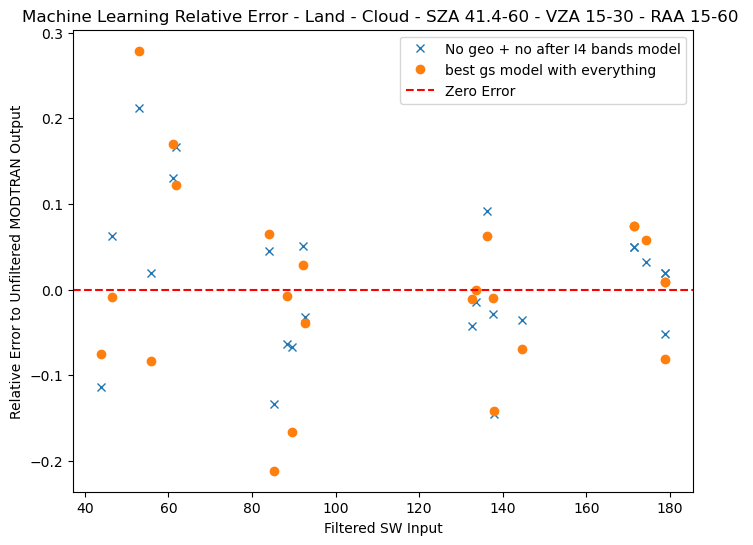

In [265]:
bm_with_bands = test_viirs_bands_refit(all_dataset, v=True, viirs_bands=True, is_sw=True,
                                 selected_viirs_bands=['SZA', 'VZA', 'RAZ','Shortwave Filtered Rads (Integrated)',
                                                       'M1', 'M2','M3', 'M4', 'I1', 'M5', 'DNB', 'M6', 'I2', 'M7',
                                                       'M8', 'M9', 'I3', 'M10', 'M11'],  best_params=best, use_groups=True)

bm_with_bands_pe = calculate_pe(matt_test_data, ['SZA', 'VZA', 'RAZ','Shortwave Filtered Rads (Integrated)',
                                        'M1', 'M2','M3', 'M4', 'I1', 'M5', 'DNB', 'M6', 'I2', 'M7',
                                        'M8', 'M9', 'I3', 'M10', 'M11'], bm_with_bands['Final_Model'])

display_pe(sw_input, bm_with_bands_pe, test_refit_pe, "No geo + no after I4 bands model", "best gs model with everything")

Using selected VIIRS bands: ['Shortwave Filtered Rads (Integrated)', 'M1', 'M2', 'M3', 'M4', 'I1', 'M5', 'DNB', 'M6', 'I2', 'M7', 'M8', 'M9', 'I3', 'M10', 'M11']
Index(['Shortwave Filtered Rads (Integrated)', 'M1', 'M2', 'M3', 'M4', 'I1',
       'M5', 'DNB', 'M6', 'I2', 'M7', 'M8', 'M9', 'I3', 'M10', 'M11'],
      dtype='object')
Train (4955, 16), Val (620, 16), Test (620, 16)
Train scenes: ['Snow' 'Land' 'Deep Convective Cloud' 'Cloudy Ocean' 'Clear Ocean']


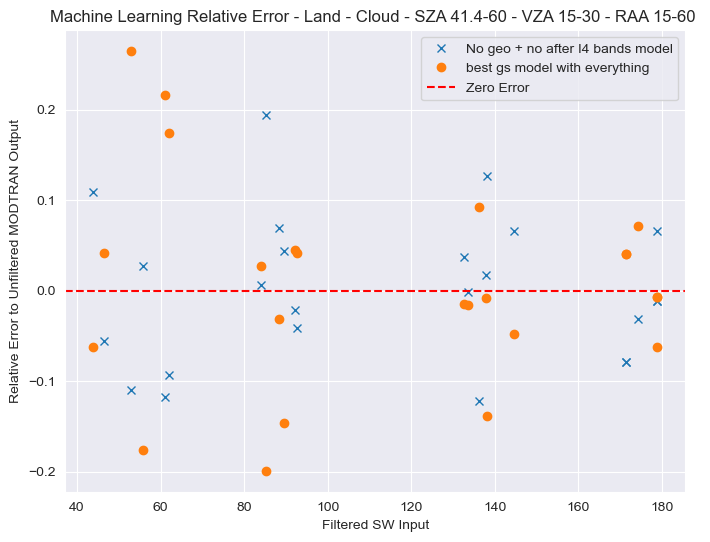

In [88]:
bm_no_bands = test_viirs_bands_refit(all_dataset, v=True, viirs_bands=True, is_sw=True,
                                 selected_viirs_bands=['Shortwave Filtered Rads (Integrated)',
                                                       'M1', 'M2','M3', 'M4', 'I1', 'M5', 'DNB', 'M6', 'I2', 'M7',
                                                       'M8', 'M9', 'I3', 'M10', 'M11'],  best_params=best, use_groups=True)

bm_no_bands_pe = calculate_pe(matt_test_data, ['Shortwave Filtered Rads (Integrated)',
                                        'M1', 'M2','M3', 'M4', 'I1', 'M5', 'DNB', 'M6', 'I2', 'M7',
                                        'M8', 'M9', 'I3', 'M10', 'M11'], bm_no_bands['Final_Model'])

display_pe(sw_input, bm_no_bands_pe, test_refit_pe, "No geo + no after I4 bands model", "best gs model with everything")

In [37]:
def display_model_metrics(results: dict) -> None:
    """
    Display key validation and test metrics from a model results dictionary.
    
    Args:
        results: Dictionary containing model evaluation metrics
    """
    print("\nValidation Metrics:")
    print("-" * 50)
    print(f"RMSE:      {results['Val_RMSE']}")
    print(f"MAE:       {results['Val_MAE']}")
    print(f"MAPE:      {results['Val_MAPE%']}%")
    print(f"R²:        {results['Val_R2']}")
    
    print("\nCross-Validation:")
    print("-" * 50)
    print(f"RMSE (mean ± std): {results['CV_RMSE_mean']} ± {results['CV_RMSE_std']}")
    print("RMSE per fold:", [f"{rmse}" for rmse in results['CV_Fold_RMSEs']])
    
    print("\nTest Metrics:")
    print("-" * 50)
    print(f"RMSE:      {results['Test_RMSE']}")
    print(f"MAE:       {results['Test_MAE']}")
    print(f"MAPE:      {results['Test_MAPE%']}%")
    print(f"R²:        {results['Test_R2']}")

In [264]:
display_model_metrics(bm_with_bands)


Validation Metrics:
--------------------------------------------------
RMSE:      1.2948602702733207
MAE:       0.46921188863755864
MAPE:      0.5506394361416761%
R²:        0.9998022406556282

Cross-Validation:
--------------------------------------------------
RMSE (mean ± std): 1.9114377958902515 ± 1.5497738626921076
RMSE per fold: ['1.0325290824810682', '0.8522466813117923', '1.1357513823349146', '4.577686190003853', '1.95897564331963']

Test Metrics:
--------------------------------------------------
RMSE:      0.9562264614753028
MAE:       0.4018763856166091
MAPE:      0.5576659918014478%
R²:        0.9999040104555659


In [246]:
display_model_metrics(bm_no_bands)


Validation Metrics:
--------------------------------------------------
RMSE:      1.3637269299391073
MAE:       0.45476236129989084
MAPE:      0.5311388364178994%
R²:        0.9997806457589804

Cross-Validation:
--------------------------------------------------
RMSE (mean ± std): 1.7242725006539037 ± 1.2686747427679945
RMSE per fold: ['1.0073564286217738', '0.7872493537913977', '0.92308723220824', '3.785634906566879', '2.118034582081228']

Test Metrics:
--------------------------------------------------
RMSE:      0.9885926381343283
MAE:       0.3851569666193503
MAPE:      0.5498186294301066%
R²:        0.9998974024100402


In [329]:
compare_global_vs_bin_fit_interactive(
    land_clear,
    scene="Land",
    sza_range=(45,60),
    vza_range=(15,30),
    raz_range=(15,60),
    degree=1,
    ml_model=bm_no_bands["Final_Model"],
    name="Land Clear, No Angles",
    ml_features=['Shortwave Filtered Rads (Integrated)', 'M1', 'M2', 'M3', 'M4', 'I1', 'M5', 'DNB', 'M6', 'I2', 'M7', 'M8', 'M9', 'I3', 'M10', 'M11']
)


For all Land Clear data:
R² Value: 0.998586330255098
Root Mean Squared Error: 1.3378094390555044
coefficients: [[0.         1.33029349]], intercept: [1.8294728]

For binned Land Clear data:
R² Value: 0.9990947501499154
Root Mean Squared Error: 0.4377100010776031
coefficients: [[0.         1.29506035]], intercept: [3.24734218]

ML Model Metrics:
R² Value: 0.9999099315212675
Root Mean Squared Error: 0.33768104870239307
Mean Absolute Percentage Error: 0.40%
Regression line coefficients: [[0.        1.0023213]], intercept: [-0.12697757]


In [330]:
compare_global_vs_bin_fit_interactive(
    land_clear,
    scene="Land",
    sza_range=(45,60),
    vza_range=(15,30),
    raz_range=(15,60),
    degree=1,
    ml_model=bm_with_bands["Final_Model"],
    name="Land Clear, w/ Angles",
    ml_features=['SZA','VZA', 'RAZ','Shortwave Filtered Rads (Integrated)', 'M1', 'M2', 'M3', 'M4', 'I1', 'M5', 'DNB', 'M6', 'I2', 'M7', 'M8', 'M9', 'I3', 'M10', 'M11']
)


For all Land Clear data:
R² Value: 0.998586330255098
Root Mean Squared Error: 1.3378094390555044
coefficients: [[0.         1.33029349]], intercept: [1.8294728]

For binned Land Clear data:
R² Value: 0.9990947501499154
Root Mean Squared Error: 0.4377100010776031
coefficients: [[0.         1.29506035]], intercept: [3.24734218]

ML Model Metrics:
R² Value: 0.9998966481458175
Root Mean Squared Error: 0.3617257371729758
Mean Absolute Percentage Error: 0.40%
Regression line coefficients: [[0.         1.00253026]], intercept: [-0.12389271]


In [331]:
compare_global_vs_bin_fit_interactive(
    land_cloudy,
    scene="Land",
    sza_range=(45,60),
    vza_range=(15,30),
    raz_range=(15,60),
    degree=1,
    ml_model=bm_with_bands["Final_Model"],
    name="Land Cloudy, w/ Angles",
    ml_features=['SZA','VZA', 'RAZ','Shortwave Filtered Rads (Integrated)', 'M1', 'M2', 'M3', 'M4', 'I1', 'M5', 'DNB', 'M6', 'I2', 'M7', 'M8', 'M9', 'I3', 'M10', 'M11']
)


For all Land Clear data:
R² Value: 0.9988693062780992
Root Mean Squared Error: 2.9173050213773744
coefficients: [[0.         1.33852318]], intercept: [2.03532587]

For binned Land Clear data:
R² Value: 0.9999222890252646
Root Mean Squared Error: 0.5160969892563709
coefficients: [[0.         1.35211162]], intercept: [1.39338561]

ML Model Metrics:
R² Value: 0.9999771211404797
Root Mean Squared Error: 0.4149793967082136
Mean Absolute Percentage Error: 0.14%
Regression line coefficients: [[0.         0.99964116]], intercept: [0.04142173]


In [339]:
compare_global_vs_bin_fit_interactive(
    land_cloudy,
    scene="Land",
    sza_range=(45,60),
    vza_range=(15,30),
    raz_range=(15,60),
    degree=1,
    ml_model=bm_no_bands["Final_Model"],
    name="Land Cloudy, no angle in model",
    ml_features=['Shortwave Filtered Rads (Integrated)', 'M1', 'M2', 'M3', 'M4', 'I1', 'M5', 'DNB', 'M6', 'I2', 'M7', 'M8', 'M9', 'I3', 'M10', 'M11']
)


For all Land Clear data:
R² Value: 0.9988693062780992
Root Mean Squared Error: 2.9173050213773744
coefficients: [[0.         1.33852318]], intercept: [2.03532587]

For binned Land Clear data:
R² Value: 0.9999222890252646
Root Mean Squared Error: 0.5160969892563709
coefficients: [[0.         1.35211162]], intercept: [1.39338561]

ML Model Metrics:
R² Value: 0.9999783661445784
Root Mean Squared Error: 0.40353044900368057
Mean Absolute Percentage Error: 0.14%
Regression line coefficients: [[0.         0.99983802]], intercept: [0.02065525]


In [348]:
unseen_data = bm_no_bands["Test_data"]
unseen_data

{'X_test': array([[2.05095865e+02, 2.13508144e+01, 2.42154201e+01, ...,
         1.95583069e-01, 1.95583069e-01, 7.03519442e-02],
        [2.01706267e+02, 2.07210589e+01, 2.34343252e+01, ...,
         1.26957898e-01, 1.26957898e-01, 4.38474369e-02],
        [1.73684409e+02, 1.97610742e+01, 2.25907330e+01, ...,
         7.81447712e-02, 7.81447712e-02, 2.02462254e-02],
        ...,
        [7.68635844e+00, 1.46556789e+00, 1.50280837e+00, ...,
         3.60085104e-02, 3.60085104e-02, 4.00839890e-03],
        [1.99495025e+01, 2.33828349e+00, 2.80972645e+00, ...,
         6.51665677e-02, 6.51665677e-02, 3.13887954e-03],
        [1.83994496e+01, 2.90502805e+00, 3.25176009e+00, ...,
         4.14653006e-02, 4.14653006e-02, 2.00750133e-03]]),
 'y_test': array([284.609397  , 279.53281578, 242.42290811, 291.45025304,
        279.44932505, 238.10041363, 299.91467139, 358.74470287,
        229.3392283 , 285.80490166, 285.80490166, 346.24297844,
        264.16787782, 239.48820612, 285.09807996, 346

In [98]:
test_data = bm_no_bands["Test_data"]
test_data.keys()

dict_keys(['X_test', 'y_test', 'meta_test'])

In [99]:
test_data["X_test"]

array([[2.05100385e+02, 2.13508144e+01, 2.42154201e+01, ...,
        1.95583069e-01, 1.95583069e-01, 7.03519442e-02],
       [2.01710600e+02, 2.07210589e+01, 2.34343252e+01, ...,
        1.26957898e-01, 1.26957898e-01, 4.38474369e-02],
       [1.73698838e+02, 1.97610742e+01, 2.25907330e+01, ...,
        7.81447712e-02, 7.81447712e-02, 2.02462254e-02],
       ...,
       [7.68707612e+00, 1.46556789e+00, 1.50280837e+00, ...,
        3.60085104e-02, 3.60085104e-02, 4.00839890e-03],
       [1.99499180e+01, 2.33828349e+00, 2.80972645e+00, ...,
        6.51665677e-02, 6.51665677e-02, 3.13887954e-03],
       [1.84001735e+01, 2.90502805e+00, 3.25176009e+00, ...,
        4.14653006e-02, 4.14653006e-02, 2.00750133e-03]])

In [100]:
test_data["meta_test"]

,Scene,Run #,SZA,VZA,RAZ,M1,M2,M3,M4,I1,...,DNB,M6,I2,M7,M8,M9,I3,M10,M11,Longwave Filtered Rads (Integrated)
7,Snow,7,0.000,0.000,0.0,21.350814,24.215420,25.906300,22.593355,70.298263,...,274.098117,12.941787,18.541671,18.541671,1.537920,0.008377,0.195583,0.195583,0.070352,42.442496
35,Snow,35,0.311,30.000,37.5,20.721059,23.434325,24.964077,21.619696,67.745736,...,268.190576,12.736542,18.450208,18.450208,1.598262,0.008599,0.126958,0.126958,0.043847,42.445827
41,Snow,41,0.311,30.000,37.5,19.761074,22.590733,24.181493,20.819755,63.261407,...,237.978049,11.114626,14.046980,14.046980,0.429904,0.031909,0.078145,0.078145,0.020246,42.824308
44,Snow,44,0.311,30.000,37.5,19.983682,22.788572,24.370129,20.931569,63.101068,...,254.983161,11.386424,16.828750,16.828750,3.413996,0.017293,5.161575,5.161575,1.119413,41.127891
66,Snow,66,0.511,30.000,142.5,20.636867,23.400767,25.004488,21.701706,68.037906,...,268.036991,12.794587,18.497068,18.497068,1.587921,0.035328,0.178039,0.178039,0.057300,40.160330
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6113,Clear Ocean,65,84.849,45.000,142.5,0.887184,0.901587,0.806500,0.487258,1.176341,...,6.541508,0.180806,0.196859,0.196859,0.020526,0.002180,0.019908,0.019908,0.002110,59.294182
6126,Clear Ocean,78,84.852,60.000,7.5,1.410101,1.610705,1.721181,1.363196,4.504269,...,19.108414,0.971646,1.551589,1.551589,0.360835,0.010632,0.539130,0.539130,0.089091,58.423041
6155,Clear Ocean,107,84.848,60.000,172.5,1.465568,1.502808,1.357491,0.828149,2.025455,...,11.033873,0.316273,0.356049,0.356049,0.039013,0.003552,0.036009,0.036009,0.004008,57.134301
6167,Clear Ocean,119,85.648,89.947,37.5,2.338283,2.809726,3.047577,2.030956,6.531766,...,26.820217,1.390422,1.648981,1.648981,0.117572,0.010867,0.065167,0.065167,0.003139,44.628441


In [90]:
test_data = bm_no_bands["Test_data"]
# X_unseen = unseen_data["X_test"]
# y_unseen = unseen_data["y_test"]
# meta_unseen = unseen_data["meta_test"]
# print(np.shape(X_unseen))
test_features = pd.DataFrame(test_data["X_test"], columns=["SZA", 'VZA', 'RAZ',
       'Shortwave Filtered Rads (Integrated)', 'M1', 'M2', 'M3', 'M4', 'I1',
       'M5', 'DNB', 'M6', 'I2', 'M7', 'M8', 'M9', 'I3', 'M10', 'M11'])
test_target = pd.Series(test_data["y_test"], name="Shortwave Unfiltered Rads (Integrated)")
full_test_df = pd.concat([test_features, test_target], axis=1)
full_test_df

ValueError: Shape of passed values is (620, 16), indices imply (620, 19)

In [ ]:
compare_global_vs_bin_fit_interactive(
    full_test_df,
    scene="Unseen Data",
    sza_range=(45,60),
    vza_range=(15,30),
    raz_range=(15,60),
    degree=1,
    ml_model=bm_no_bands["Final_Model"],
    name="Unseen Dataset, no Angles",
    ml_features=['Shortwave Filtered Rads (Integrated)', 'M1', 'M2', 'M3', 'M4', 'I1', 'M5', 'DNB', 'M6', 'I2', 'M7', 'M8', 'M9', 'I3', 'M10', 'M11']
)


For all Land Clear data:
R² Value: 0.9986356249987035
Root Mean Squared Error: 3.6050863303266962
coefficients: [[0.         1.33267894]], intercept: [2.63614691]

For binned Land Clear data:
R² Value: 0.999740553759255
Root Mean Squared Error: 1.0632507265999263
coefficients: [[0.         1.35487488]], intercept: [1.6693087]

ML Model Metrics:
R² Value: 0.9998790040510072
Root Mean Squared Error: 1.0735794936768173
Mean Absolute Percentage Error: 0.54%
Regression line coefficients: [[0.         1.00037176]], intercept: [0.02462554]


In [96]:
# def grouped_train_val_test_split(
#     df: pd.DataFrame,
#     target_col: str,
#     feature_drop: list[str],
#     train_size: float = 0.8,
#     val_size: float = 0.1,
#     random_state: int = 42
# ):
#     """Custom split grouped by Scene+Run # to avoid leakage."""
#     group_keys = df["Scene"].astype(str) + "|" + df["Run #"].astype(str)

#     print("TEST")
#     print(feature_drop)
#     X_full = df.drop(columns=feature_drop)
#     y_full = df[target_col]

#     # 1) Train vs temp (val+test)
#     gss1 = GroupShuffleSplit(n_splits=1, train_size=train_size, random_state=random_state)
#     tr_idx, temp_idx = next(gss1.split(X_full, y_full, groups=group_keys))

#     # 2) Val vs test from temp
#     gss2 = GroupShuffleSplit(n_splits=1, train_size=0.5, random_state=random_state+1)
#     val_rel, test_rel = next(gss2.split(
#         X_full.iloc[temp_idx], y_full.iloc[temp_idx], groups=group_keys.iloc[temp_idx]
#     ))
#     val_idx = temp_idx[val_rel]
#     test_idx = temp_idx[test_rel]

#     def pack(idxs):
#         return (
#             X_full.iloc[idxs].to_numpy(),
#             y_full.iloc[idxs].to_numpy(),
#             df.iloc[idxs][["Scene", "Run #", "SZA", "VZA", "RAZ"]]  # keep metadata
#         )

#     return pack(tr_idx), pack(val_idx), pack(test_idx)



# def test_viirs_bands_refit(
#     dataset: pd.DataFrame,
#     v: bool,
#     viirs_bands: bool,
#     is_sw: bool = True,
#     selected_viirs_bands: list[str] | None = None,
#     best_params: dict | None = None,
#     use_groups: bool = True,
#     n_splits: int = 5,
#     refit_on_val: bool = True  # <-- NEW FLAG
# ):
#     """
#     Train a RandomForest model, validate on held-out data, and optionally refit
#     on train+val before evaluating on the test set.
#     """
#     ret = {}
#     dataset_ = dataset.reset_index(drop=True)

#     # --- target col setup ---
#     target_col = "Shortwave Unfiltered Rads (Integrated)" if is_sw else "Longwave Unfiltered Rads (Integrated)"
#     filtered_sw = "Shortwave Filtered Rads (Integrated)"
#     filtered_lw = "Longwave Filtered Rads (Integrated)"

#     # --- columns to drop ---
#     if is_sw:
#         columns_to_drop = [
#             "Run #","Scene", "Shortwave Unfiltered Rads (Integrated)",
#             "Longwave Unfiltered Rads (Integrated)", filtered_lw,
#             "Scaled Longwave Unfiltered","Scaled Longwave Filtered",
#             "Scaled Shortwave Unfiltered","Scaled Shortwave Filtered","Cloud"
#         ]
#     else:
#         columns_to_drop = [
#             "Run #","Scene",
#             "Shortwave Unfiltered Rads (Integrated)", filtered_sw,
#             "Scaled Longwave Unfiltered","Scaled Longwave Filtered",
#             "Scaled Shortwave Unfiltered","Scaled Shortwave Filtered","Cloud"
#         ]

#     all_viirs_bands = ['SZA','VZA','RAZ','M1','M2','M3','M4','I1','M5','DNB','M6','I2','M7','M8','M9',
#                        'I3','M10','M11','I4','M12','M13','M14','M15','I5','M16']

#     if not viirs_bands:
#         columns_to_drop.extend(all_viirs_bands)
#     elif selected_viirs_bands is not None:
#         columns_to_drop.extend([b for b in all_viirs_bands if b not in selected_viirs_bands])
#         if v: print(f"Using selected VIIRS bands: {selected_viirs_bands}")
#     else:
#         if v: print("Using all VIIRS bands.")

#     # --- custom split grouped by Scene|Run ---
#     (X_tr, y_tr, meta_tr), (X_val, y_val, meta_val), (X_te, y_te, meta_te) = grouped_train_val_test_split(
#         dataset_,
#         target_col=target_col,
#         feature_drop=columns_to_drop,
#         train_size=0.8,
#         val_size=0.1,
#         random_state=42
#     )
#     # X_tr_dropped, X_val_dropped, X_te_dropped = X_tr.drop(columns=columns_to_drop), X_val.drop(columns=columns_to_drop), X_te.drop(columns=columns_to_drop)

#     if v:
#         print(f"Train {X_tr.shape}, Val {X_val.shape}, Test {X_te.shape}")
#         print("Train scenes:", meta_tr["Scene"].unique())

#     # --- params ---
#     params = best_params or {
#         'max_depth': 16,
#         'max_features': 'log2',
#         'max_samples': None,
#         'min_samples_leaf': 1,
#         'min_samples_split': 2,
#         'n_estimators': 600,
#         'random_state': 42,
#         'bootstrap': True
#     }

#     # --- model training on train only ---
#     model = RandomForestRegressor(**params)
#     model.fit(X_tr, y_tr)
#     y_val_pred = model.predict(X_val)

#     # --- validation metrics ---
#     ret["Val_RMSE"] = root_mean_squared_error(y_val, y_val_pred)
#     ret["Val_MAE"]  = mean_absolute_error(y_val, y_val_pred)
#     ret["Val_MAPE%"] = mean_absolute_percentage_error(y_val, y_val_pred) * 100
#     ret["Val_R2"]   = r2_score(y_val, y_val_pred)

#     # --- cross-validation (on training set) ---
#     if use_groups:
#         groups = dataset_["Scene"].astype(str) + "|" + dataset_["Run #"].astype(str)
#         # groups = dataset_[["Scene", "Run #"]].astype(str).agg("|".join, axis=1)
#         # groups = groups.loc[X_tr.index]
#         splitter = GroupKFold(n_splits=n_splits)
#         folds = list(splitter.split(X_tr, y_tr, groups.loc[y_tr.index]))
#         # folds = list(splitter.split(X_tr, y_tr, groups))
#     else:
#         from sklearn.model_selection import KFold
#         folds = list(KFold(n_splits=n_splits, shuffle=True, random_state=42).split(X_tr, y_tr))

#     cv_scores_neg = cross_val_score(
#         RandomForestRegressor(**params),
#         X_tr, y_tr, cv=folds,
#         scoring="neg_root_mean_squared_error",
#         n_jobs=-1
#     )
#     # if use_groups:
#     #     groups = dataset_[["Scene", "Run #"]].astype(str).agg("|".join, axis=1)
#     #     groups = groups.loc[X_tr.index]  # align properly!
#     #     splitter = GroupKFold(n_splits=n_splits)
#     #     folds = list(splitter.split(X_tr, y_tr, groups))
#     # else:
#     #     from sklearn.model_selection import KFold
#     #     folds = list(KFold(n_splits=n_splits, shuffle=True, random_state=42).split(X_tr, y_tr))

#     # cv_scores_neg = cross_val_score(
#     #     RandomForestRegressor(**params),
#     #     X_tr, y_tr,
#     #     cv=folds,
#     #     scoring="neg_root_mean_squared_error",
#     #     n_jobs=-1
#     # )
    
#     ret["CV_Fold_RMSEs"] = -cv_scores_neg
#     ret["CV_RMSE_mean"]  = float(np.mean(-cv_scores_neg))
#     ret["CV_RMSE_std"]   = float(np.std(-cv_scores_neg, ddof=1))

#     # --- optional refit ---
#     if refit_on_val:
#         X_trval = pd.concat([X_tr, X_val], axis=0)
#         y_trval = pd.concat([y_tr, y_val], axis=0)
#         final_model = RandomForestRegressor(**params)
#         final_model.fit(X_trval, y_trval)
#         y_test_pred = final_model.predict(X_te)
#         ret["Test_RMSE"] = root_mean_squared_error(y_te, y_test_pred)
#         ret["Test_MAE"]  = mean_absolute_error(y_te, y_test_pred)
#         ret["Test_MAPE%"] = mean_absolute_percentage_error(y_te, y_test_pred) * 100
#         ret["Test_R2"]   = r2_score(y_te, y_test_pred)
#         ret["Final_Model"] = final_model
#     else:
#         ret["Final_Model"] = model  # just the train-only fit

#     # --- return useful data too ---
#     ret["Params_Used"] = params
#     ret["Train_data"] = {"X_tr": X_tr, "y_tr": y_tr, "meta_tr": meta_tr}
#     ret["Validation_data"] = {"X_val": X_val, "y_val": y_val, "meta_val": meta_val}
#     ret["Test_data"] = {"X_test": X_te, "y_test": y_te, "meta_test": meta_te}
#     ret["Drop"] = columns_to_drop

#     return ret

def calculate_pe(test_df, feature_cols, model, is_sw=True):
    """
    Calculate percent error between predicted and actual unfiltered radiance values.
    Handles feature alignment automatically.
    """
    target_col = (
        "Shortwave Unfiltered Rads (Integrated)"
        if is_sw else
        "Longwave Unfiltered Rads (Integrated)"
    )
    X = test_df[feature_cols].copy()
    y_true = test_df[target_col].values

    # Ensure column alignment with model
    expected_features = getattr(model, "feature_names_in_", None)
    if expected_features is not None:
        missing = set(expected_features) - set(X.columns)
        extra = set(X.columns) - set(expected_features)

        if missing:
            print(f"[Warning] Missing features: {missing}. Adding as zeros.")
            for m in missing:
                X[m] = 0.0

        if extra:
            print(f"[Warning] Extra features not in model: {extra}. Dropping them.")
            X = X.drop(columns=list(extra))

        X = X[expected_features]  # reorder exactly as model expects

    # Predict + PE calc
    y_pred = model.predict(X)
    pe = (y_true - y_pred) / y_true * 100
    return pe



import pandas as pd
from sklearn.model_selection import GroupShuffleSplit, GroupKFold, KFold, cross_val_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import (
    mean_absolute_error,
    mean_absolute_percentage_error,
    root_mean_squared_error,
    r2_score,
)

# --------------------------------------------------------------------------
# GROUPED SPLIT FUNCTION
# --------------------------------------------------------------------------
def grouped_train_val_test_split(
    df: pd.DataFrame,
    target_col: str,
    feature_drop: list[str],
    train_size: float = 0.8,
    val_size: float = 0.1,
    random_state: int = 42
):
    """
    Custom split grouped by Scene+Run # to avoid leakage.
    Returns numpy arrays for features and targets (like the original version).
    """
    group_keys = df["Scene"].astype(str) + "|" + df["Run #"].astype(str)

    # Drop unwanted columns and isolate target
    X_full = df.drop(columns=feature_drop)
    y_full = df[target_col]

    print(X_full.columns)

    # --- Train vs Temp (Val + Test) ---
    gss1 = GroupShuffleSplit(n_splits=1, train_size=train_size, random_state=random_state)
    tr_idx, temp_idx = next(gss1.split(X_full, y_full, groups=group_keys))

    # --- Val vs Test from Temp ---
    gss2 = GroupShuffleSplit(n_splits=1, train_size=0.5, random_state=random_state + 1)
    val_rel, test_rel = next(
        gss2.split(X_full.iloc[temp_idx], y_full.iloc[temp_idx], groups=group_keys.iloc[temp_idx])
    )
    val_idx = temp_idx[val_rel]
    test_idx = temp_idx[test_rel]

    def pack(idxs):
        return (
            X_full.iloc[idxs].to_numpy(),                     # X as np.ndarray
            y_full.iloc[idxs].to_numpy(),                     # y as np.ndarray
            df.iloc[idxs][["Scene", "Run #", "SZA", "VZA", "RAZ", 'M1', 'M2', 'M3', 'M4', 'I1', 'M5', 'DNB', 'M6', 'I2', 'M7', 'M8', 'M9', 'I3', 'M10', 'M11', 'Shortwave Filtered Rads (Integrated)']],  # metadata
            idxs                                               # indices for alignment
        )

    return pack(tr_idx), pack(val_idx), pack(test_idx)


# --------------------------------------------------------------------------
# MAIN MODEL TRAINING / REFIT FUNCTION
# --------------------------------------------------------------------------
def test_viirs_bands_refit(
    dataset: pd.DataFrame,
    v: bool,
    viirs_bands: bool,
    is_sw: bool = True,
    selected_viirs_bands: list[str] | None = None,
    best_params: dict | None = None,
    use_groups: bool = True,
    n_splits: int = 5,
    refit_on_val: bool = True
):
    """
    Train a RandomForest model, validate on held-out data, and optionally refit
    on train+val before evaluating on the test set.
    """
    ret = {}
    dataset_ = dataset.reset_index(drop=True)

    # --- Target column setup ---
    target_col = "Shortwave Unfiltered Rads (Integrated)" if is_sw else "Longwave Unfiltered Rads (Integrated)"
    filtered_sw = "Shortwave Filtered Rads (Integrated)"
    filtered_lw = "Longwave Filtered Rads (Integrated)"

    # --- Columns to drop ---
    if is_sw:
        columns_to_drop = [
            "Run #","Scene", "Shortwave Unfiltered Rads (Integrated)", 'Split Shortwave Filtered Rads (Integrated)', 'Total Filtered Rads (Integrated)',
            "Longwave Unfiltered Rads (Integrated)", filtered_lw,
            "Scaled Longwave Unfiltered","Scaled Longwave Filtered",
            "Scaled Shortwave Unfiltered","Scaled Shortwave Filtered","Cloud"
        ]
    else:
        columns_to_drop = [
            "Run #","Scene",
            "Shortwave Unfiltered Rads (Integrated)", filtered_sw, 'Split Shortwave Filtered Rads (Integrated)', 'Total Filtered Rads (Integrated)', 'Longwave Unfiltered Rads (Integrated)',
            "Scaled Longwave Unfiltered","Scaled Longwave Filtered",
            "Scaled Shortwave Unfiltered","Scaled Shortwave Filtered","Cloud"
        ]

    all_viirs_bands = [
        'SZA','VZA','RAZ','M1','M2','M3','M4','I1','M5','DNB','M6','I2',
        'M7','M8','M9','I3','M10','M11','I4','M12','M13','M14','M15','I5','M16'
    ]

    if not viirs_bands:
        columns_to_drop.extend(all_viirs_bands)
    elif selected_viirs_bands is not None:
        columns_to_drop.extend([b for b in all_viirs_bands if b not in selected_viirs_bands])
        if v:
            print(f"Using selected VIIRS bands: {selected_viirs_bands}")
    else:
        if v:
            print("Using all VIIRS bands.")

    # --- Custom grouped split ---
    (X_tr, y_tr, meta_tr, tr_idx), (X_val, y_val, meta_val, val_idx), (X_te, y_te, meta_te, te_idx) = grouped_train_val_test_split(
        dataset_,
        target_col=target_col,
        feature_drop=columns_to_drop,
        train_size=0.8,
        val_size=0.1,
        random_state=42
    )

    if v:
        print(f"Train {X_tr.shape}, Val {X_val.shape}, Test {X_te.shape}")
        print("Train scenes:", meta_tr["Scene"].unique())

    # --- Model parameters ---
    params = best_params or {
        'max_depth': 16,
        'max_features': 'log2',
        'max_samples': None,
        'min_samples_leaf': 1,
        'min_samples_split': 2,
        'n_estimators': 600,
        'random_state': 42,
        'bootstrap': True
    }

    # --- Train model ---
    model = RandomForestRegressor(**params)
    model.fit(X_tr, y_tr)
    y_val_pred = model.predict(X_val)

    # --- Validation metrics ---
    ret["Val_RMSE"] = root_mean_squared_error(y_val, y_val_pred)
    ret["Val_MAE"] = mean_absolute_error(y_val, y_val_pred)
    ret["Val_MAPE%"] = mean_absolute_percentage_error(y_val, y_val_pred) * 100
    ret["Val_R2"] = r2_score(y_val, y_val_pred)

    # --- Cross-validation (on training set only) ---
    if use_groups:
        groups = dataset_["Scene"].astype(str) + "|" + dataset_["Run #"].astype(str)
        splitter = GroupKFold(n_splits=n_splits)
        folds = list(splitter.split(X_tr, y_tr, groups.iloc[tr_idx]))
    else:
        splitter = KFold(n_splits=n_splits, shuffle=True, random_state=42)
        folds = list(splitter.split(X_tr, y_tr))

    cv_scores_neg = cross_val_score(
        RandomForestRegressor(**params),
        X_tr, y_tr,
        cv=folds,
        scoring="neg_root_mean_squared_error",
        n_jobs=-1
    )

    ret["CV_Fold_RMSEs"] = -cv_scores_neg
    ret["CV_RMSE_mean"] = float(np.mean(-cv_scores_neg))
    ret["CV_RMSE_std"] = float(np.std(-cv_scores_neg, ddof=1))

    # --- Optional refit on train + val ---
    if refit_on_val:
        X_trval = np.concatenate([X_tr, X_val], axis=0)
        y_trval = np.concatenate([y_tr, y_val], axis=0)
        final_model = RandomForestRegressor(**params)
        final_model.fit(X_trval, y_trval)
        y_test_pred = final_model.predict(X_te)

        ret["Test_RMSE"] = root_mean_squared_error(y_te, y_test_pred)
        ret["Test_MAE"] = mean_absolute_error(y_te, y_test_pred)
        ret["Test_MAPE%"] = mean_absolute_percentage_error(y_te, y_test_pred) * 100
        ret["Test_R2"] = r2_score(y_te, y_test_pred)
        ret["Final_Model"] = final_model
    else:
        ret["Final_Model"] = model

    # --- Return useful outputs ---
    ret["Params_Used"] = params
    ret["Train_data"] = {"X_tr": X_tr, "y_tr": y_tr, "meta_tr": meta_tr}
    ret["Validation_data"] = {"X_val": X_val, "y_val": y_val, "meta_val": meta_val}
    ret["Test_data"] = {"X_test": X_te, "y_test": y_te, "meta_test": meta_te}
    ret["Drop"] = columns_to_drop

    return ret


Using selected VIIRS bands: ['SZA', 'VZA', 'RAZ', 'Shortwave Filtered Rads (Integrated)', 'M1', 'M2', 'M3', 'M4', 'I1', 'M5', 'DNB', 'M6', 'I2', 'M7', 'M8', 'M9', 'I3', 'M10', 'M11']
Index(['SZA', 'VZA', 'RAZ', 'Shortwave Filtered Rads (Integrated)', 'M1', 'M2',
       'M3', 'M4', 'I1', 'M5', 'DNB', 'M6', 'I2', 'M7', 'M8', 'M9', 'I3',
       'M10', 'M11'],
      dtype='object')
Train (4955, 19), Val (620, 19), Test (620, 19)
Train scenes: ['Snow' 'Land' 'Deep Convective Cloud' 'Cloudy Ocean' 'Clear Ocean']


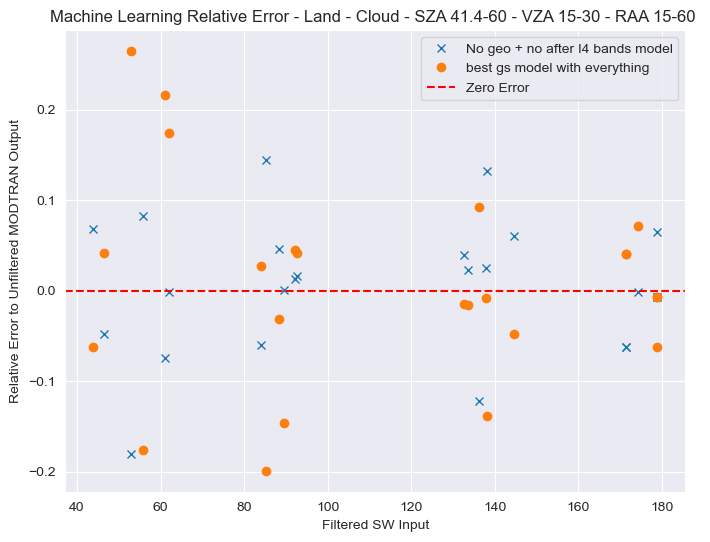

In [97]:
bm_with_bands = test_viirs_bands_refit(all_dataset, v=True, viirs_bands=True, is_sw=True,
                                 selected_viirs_bands=['SZA', 'VZA', 'RAZ','Shortwave Filtered Rads (Integrated)',
                                                       'M1', 'M2','M3', 'M4', 'I1', 'M5', 'DNB', 'M6', 'I2', 'M7',
                                                       'M8', 'M9', 'I3', 'M10', 'M11'],  best_params=best, use_groups=True)

bm_with_bands_pe = calculate_pe(matt_test_data, ['SZA', 'VZA', 'RAZ','Shortwave Filtered Rads (Integrated)',
                                        'M1', 'M2','M3', 'M4', 'I1', 'M5', 'DNB', 'M6', 'I2', 'M7',
                                        'M8', 'M9', 'I3', 'M10', 'M11'], bm_with_bands['Final_Model'])

display_pe(sw_input, bm_with_bands_pe, test_refit_pe, "No geo + no after I4 bands model", "best gs model with everything")

In [336]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.inspection import permutation_importance

def plot_feature_importance(estimator, X, y, feature_names=None, n_repeats=10, n_jobs=2, figsize=(10, 6)):
    """
    Calculate and plot permutation importance for a fitted estimator.
    
    Parameters:
    -----------
    estimator : fitted sklearn estimator
        The trained model to evaluate
    X : array-like
        Features to evaluate importance on
    y : array-like
        Target variable
    feature_names : list, optional
        List of feature names. If None, will use X.columns if available
    n_repeats : int, default=10
        Number of times to permute each feature
    n_jobs : int, default=-1
        Number of parallel jobs. -1 means using all processors
    figsize : tuple, default=(10, 6)
        Figure size for the plot
        
    Returns:
    --------
    importance_df : pd.DataFrame
        DataFrame containing importance scores for each feature
    """
    
    # Calculate permutation importance
    result = permutation_importance(
        estimator, X, y,
        n_repeats=n_repeats,
        random_state=42,
        n_jobs=n_jobs
    )
    
    # Get feature names
    if feature_names is None:
        if hasattr(X, 'columns'):
            feature_names = X.columns
        else:
            feature_names = [f"Feature {i}" for i in range(X.shape[1])]
    
    # Create DataFrame with importance scores
    importance_df = pd.DataFrame({
        'Feature': feature_names,
        'Importance Mean': result.importances_mean,
        'Importance Std': result.importances_std
    })
    
    # Sort by importance
    importance_df = importance_df.sort_values('Importance Mean', ascending=False)
    
    # Create plot
    plt.figure(figsize=figsize)
    
    # Plot bars with error bars
    plt.errorbar(
        x=importance_df['Importance Mean'],
        y=np.arange(len(importance_df)),
        xerr=importance_df['Importance Std'],
        fmt='o',
        capsize=5,
        capthick=2,
        elinewidth=2,
        markersize=8
    )
    
    # Add feature names and customize plot
    plt.yticks(np.arange(len(importance_df)), importance_df['Feature'])
    plt.xlabel('Mean Decrease in Performance (with std)')
    plt.title('Feature Importance (Permutation)')
    
    # Add grid
    plt.grid(True, alpha=0.3)
    
    # Adjust layout
    plt.tight_layout()
    
    return importance_df

# Example usage with your model:

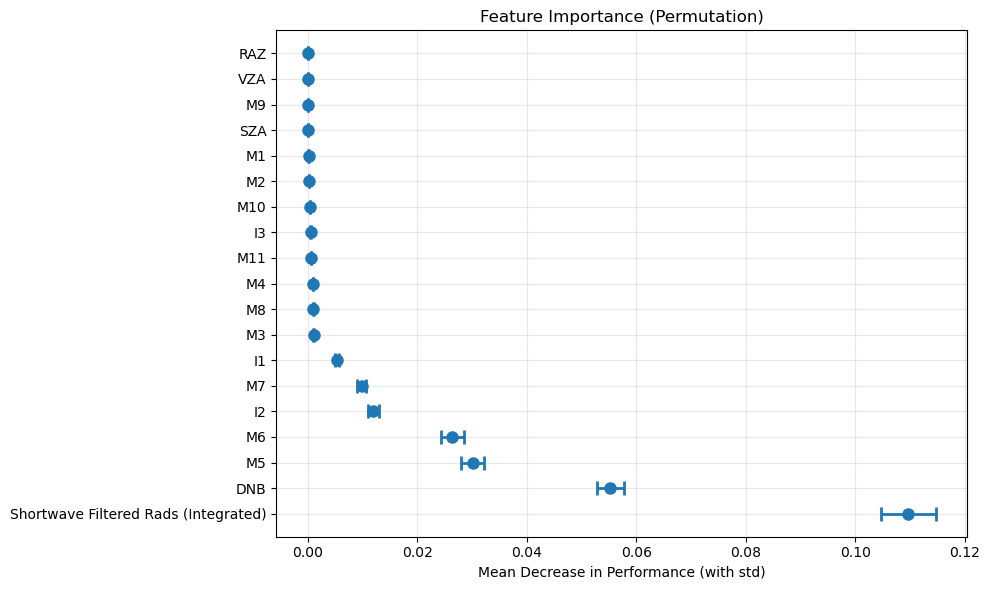

In [337]:
feature_names = ['SZA', 'VZA', 'RAZ', 'Shortwave Filtered Rads (Integrated)',
                'M1', 'M2', 'M3', 'M4', 'I1', 'M5', 'DNB', 'M6', 'I2', 'M7',
                'M8', 'M9', 'I3', 'M10', 'M11']

# Run importance analysis
importance_results = plot_feature_importance(
    estimator=bm_with_bands["Final_Model"],
    X=test_data["X_test"],
    y=test_data["y_test"],
    feature_names=feature_names,
    n_repeats=10
)

In [3]:
wavelengths = land_data[0].rads[0, 0, :]

In [4]:
from matt_code.convert_tp7 import load_all_runs_from_tp7
from matt_code.make_srf import get_interpolated_srf

In [5]:
ssw_filter = get_interpolated_srf("ssw", interpolation_points=wavelengths)
sw_filter = get_interpolated_srf("sw", interpolation_points=wavelengths)
lw_filter = get_interpolated_srf("lw", interpolation_points=wavelengths)
total_filter = get_interpolated_srf("total", interpolation_points=wavelengths)

In [8]:
for i in ssw_filter:
    print(i)

0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0


In [9]:
len(ssw_filter)

4000

In [4]:
all_dataset

,Scene,SZA,VZA,RAZ,Cloud,Run #,Shortwave Unfiltered Rads (Integrated),Longwave Unfiltered Rads (Integrated),Shortwave Filtered Rads (Integrated),Longwave Filtered Rads (Integrated),...,M12,M13,M14,M15,I5,M16,Scaled Shortwave Filtered,Scaled Shortwave Unfiltered,Scaled Longwave Filtered,Scaled Longwave Unfiltered
0,Snow,0.000,0.000,0.0,0,0,307.528673,64.630148,223.028925,41.965232,...,0.004348,0.001302,0.000088,0.000138,0.000294,0.000190,0.460896,0.500871,0.492032,0.477688
1,Snow,0.000,0.000,0.0,1,1,308.989576,61.707542,224.248333,40.116431,...,0.013530,0.005802,0.000327,0.000176,0.000381,0.000226,0.463442,0.503278,0.453486,0.439632
2,Snow,0.000,0.000,0.0,1,2,307.570444,65.121000,222.762654,42.268825,...,0.003081,0.000960,0.000084,0.000111,0.000276,0.000193,0.460340,0.500940,0.498362,0.484079
3,Snow,0.000,0.000,0.0,1,3,367.808738,53.795463,271.728794,35.110162,...,0.347688,0.160067,0.012621,0.007502,0.010138,0.003258,0.562603,0.600195,0.349109,0.336606
4,Snow,0.000,0.000,0.0,1,4,323.988001,63.367576,236.912900,41.203241,...,0.377263,0.147548,0.011686,0.006478,0.008392,0.002541,0.489892,0.527991,0.476145,0.461247
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
142,Clear Ocean,83.845,89.947,172.5,0,142,55.161028,68.826211,38.618218,44.481189,...,0.002860,0.000531,0.000014,0.000010,0.000013,0.000005,0.075762,0.085044,0.544488,0.532326
143,Clear Ocean,83.845,89.947,172.5,0,143,58.683832,68.796818,41.352139,44.467129,...,0.004841,0.000933,0.000018,0.000013,0.000016,0.000006,0.081471,0.090849,0.544195,0.531943
144,Clear Ocean,83.845,89.947,172.5,0,144,62.944481,68.745825,44.653951,44.440408,...,0.008280,0.001732,0.000027,0.000019,0.000023,0.000008,0.088367,0.097869,0.543638,0.531279
145,Clear Ocean,83.845,89.947,172.5,0,145,68.463058,68.719250,48.915804,44.427437,...,0.013350,0.003030,0.000036,0.000023,0.000027,0.000009,0.097268,0.106962,0.543367,0.530933


For all Land Clear data:
R² Value: 0.9989333055572432
Root Mean Squared Error: 2.7176164107056473
coefficients: [[0.         1.33836912]], intercept: [1.89962049]

For binned Land Clear data:
R² Value: 0.9999086722226891
Root Mean Squared Error: 0.6339710917547905
coefficients: [[0.         1.35340604]], intercept: [1.09064957]


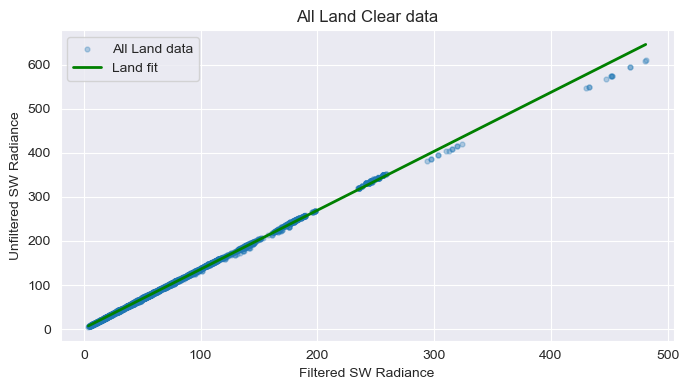

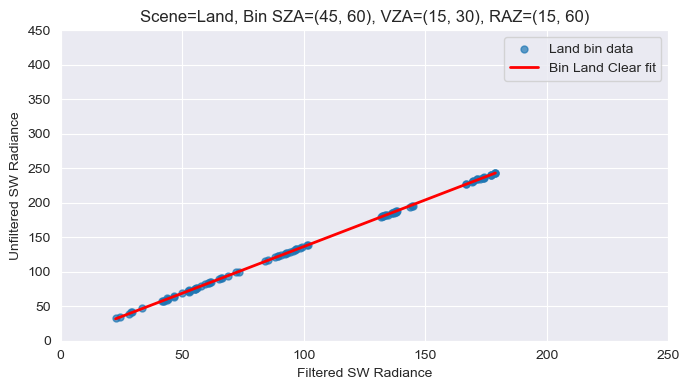

In [8]:
compare_global_vs_bin_fit(
    land_all,
    scene="Land",
    sza_range=(45,60),
    vza_range=(15,30),
    raz_range=(15,60),
    degree=1  # linear, or 2 for quadratic
)

For all Land Clear data:
R² Value: 0.9998996144555796
Root Mean Squared Error: 0.14006532846585001
coefficients: [[0.         1.60181915]], intercept: [-2.47461287]

For binned Land Clear data:
R² Value: 0.9998954750513278
Root Mean Squared Error: 0.143699915302459
coefficients: [[0.         1.60434242]], intercept: [-2.60608857]


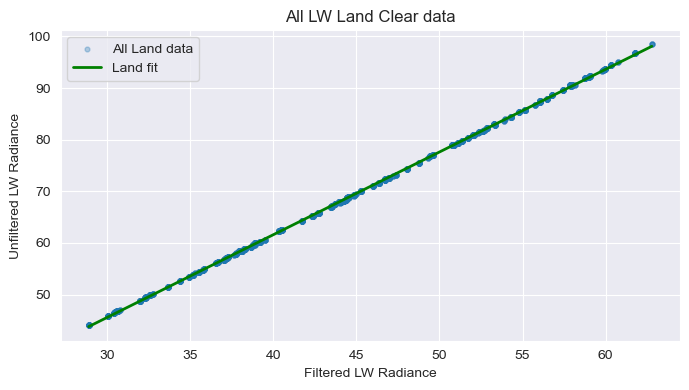

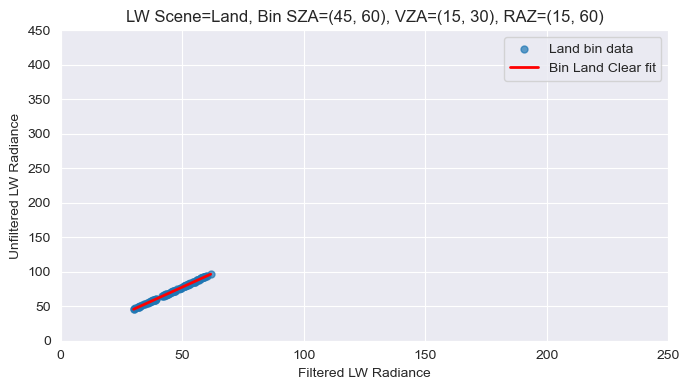

In [11]:
compare_global_vs_bin_fit(
    land_all,
    scene="Land",
    sza_range=(45,60),
    vza_range=(15,30),
    raz_range=(15,60),
    degree=1,  # linear, or 2 for quadratic
    is_sw=False
)

In [29]:
gridsearch_sw = random_grid_search(all_dataset, v=True, viirs_bands=True, is_sw=True)

Using all VIIRS bands
Input Features: ['Shortwave Filtered Rads (Integrated)', 'M1', 'M2', 'M3', 'M4', 'I1', 'M5', 'DNB', 'M6', 'I2', 'M7', 'M8', 'M9', 'I3', 'M10', 'M11', 'I4', 'M12', 'M13', 'M14', 'M15', 'I5', 'M16']
Prediction Feature(s): ['Shortwave Unfiltered Rads (Integrated)']
Fitting 5 folds for each of 60 candidates, totalling 300 fits


/opt/anaconda3/envs/test/lib/python3.11/site-packages/sklearn/base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
/opt/anaconda3/envs/test/lib/python3.11/site-packages/sklearn/base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
/opt/anaconda3/envs/test/lib/python3.11/site-packages/sklearn/base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
/opt/anaconda3/envs/test/lib/python3.11/site-packages/sklearn/base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Pleas

Fitting 5 folds for each of 270 candidates, totalling 1350 fits


/opt/anaconda3/envs/test/lib/python3.11/site-packages/sklearn/base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
/opt/anaconda3/envs/test/lib/python3.11/site-packages/sklearn/base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
/opt/anaconda3/envs/test/lib/python3.11/site-packages/sklearn/base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
/opt/anaconda3/envs/test/lib/python3.11/site-packages/sklearn/base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Pleas

In [30]:
gridsearch_sw

{'rand_best_params': {'n_estimators': 200,
  'min_samples_split': 4,
  'min_samples_leaf': 2,
  'max_samples': None,
  'max_features': 'log2',
  'max_depth': 16},
 'rand_cv_rmse': 1.1531017268594774,
 'grid_best_params': {'max_depth': 16,
  'max_features': 'log2',
  'max_samples': None,
  'min_samples_leaf': 1,
  'min_samples_split': 2,
  'n_estimators': 400},
 'grid_cv_rmse': 0.9906533606517426}

In [24]:
gridsearch_lw = random_grid_search(all_dataset, v=True, viirs_bands=True, is_sw=False)

Using all VIIRS bands
Input Features: ['SZA', 'VZA', 'RAZ', 'Longwave Filtered Rads (Integrated)', 'M1', 'M2', 'M3', 'M4', 'I1', 'M5', 'DNB', 'M6', 'I2', 'M7', 'M8', 'M9', 'I3', 'M10', 'M11', 'I4', 'M12', 'M13', 'M14', 'M15', 'I5', 'M16']
Prediction Feature(s): ['Longwave Unfiltered Rads (Integrated)']
Fitting 5 folds for each of 60 candidates, totalling 300 fits


/opt/anaconda3/envs/test/lib/python3.11/site-packages/sklearn/base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
/opt/anaconda3/envs/test/lib/python3.11/site-packages/sklearn/base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
/opt/anaconda3/envs/test/lib/python3.11/site-packages/sklearn/base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
/opt/anaconda3/envs/test/lib/python3.11/site-packages/sklearn/base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Pleas

Fitting 5 folds for each of 540 candidates, totalling 2700 fits


/opt/anaconda3/envs/test/lib/python3.11/site-packages/sklearn/base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
/opt/anaconda3/envs/test/lib/python3.11/site-packages/sklearn/base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
/opt/anaconda3/envs/test/lib/python3.11/site-packages/sklearn/base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
/opt/anaconda3/envs/test/lib/python3.11/site-packages/sklearn/base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Pleas

In [25]:
gridsearch_lw

{'rand_best_params': {'n_estimators': 200,
  'min_samples_split': 12,
  'min_samples_leaf': 5,
  'max_samples': 0.9,
  'max_features': 0.5,
  'max_depth': 16},
 'rand_cv_rmse': 0.2826019583032593,
 'grid_best_params': {'max_depth': 16,
  'max_features': 0.5,
  'max_samples': 0.9,
  'min_samples_leaf': 4,
  'min_samples_split': 10,
  'n_estimators': 1000},
 'grid_cv_rmse': 0.2565504086803322}

In [35]:
lw_best = {'max_depth': 16,
  'max_features': 0.5,
  'max_samples': 0.9,
  'min_samples_leaf': 4,
  'min_samples_split': 10,
  'n_estimators': 1000}

sw_2nd_best = {'max_depth': 16,
  'max_features': 'log2',
  'max_samples': None,
  'min_samples_leaf': 1,
  'min_samples_split': 2,
  'n_estimators': 400}

best

{'max_depth': 16,
 'max_features': 'log2',
 'max_samples': None,
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'n_estimators': 800}

Using selected VIIRS bands: ['SZA', 'VZA', 'RAZ', 'Shortwave Filtered Rads (Integrated)', 'M1', 'M2', 'M3', 'M4', 'I1', 'M5', 'DNB', 'M6', 'I2', 'M7', 'M8', 'M9', 'I3', 'M10', 'M11']
Train (4955, 19), Val (620, 19), Test (620, 19)
Train scenes: ['Snow' 'Land' 'Deep Convective Cloud' 'Cloudy Ocean' 'Clear Ocean']
(24,) [ 0.12973496  0.04275451 -0.01826111  0.06479947  0.19671594 -0.05966528
 -0.04859089  0.06516627  0.09666918  0.1460578   0.12801814  0.01855418
 -0.10304799  0.06031752 -0.0649627   0.00375297  0.06818523 -0.12237464
 -0.15583368  0.00375065 -0.0614918  -0.07706334 -0.04449264 -0.07506511]


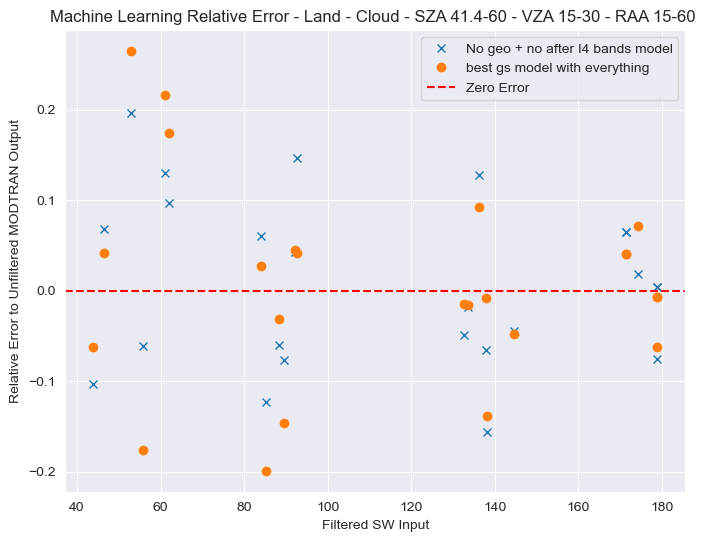

In [34]:
bm_with_bands = test_viirs_bands_refit(all_dataset, v=True, viirs_bands=True, is_sw=True,
                                 selected_viirs_bands=['SZA', 'VZA', 'RAZ','Shortwave Filtered Rads (Integrated)',
                                                       'M1', 'M2','M3', 'M4', 'I1', 'M5', 'DNB', 'M6', 'I2', 'M7',
                                                       'M8', 'M9', 'I3', 'M10', 'M11'],  best_params=sw_2nd_best, use_groups=True)

bm_with_bands_pe = calculate_pe(matt_test_data, ['SZA', 'VZA', 'RAZ','Shortwave Filtered Rads (Integrated)',
                                        'M1', 'M2','M3', 'M4', 'I1', 'M5', 'DNB', 'M6', 'I2', 'M7',
                                        'M8', 'M9', 'I3', 'M10', 'M11'], bm_with_bands['Final_Model'])

display_pe(sw_input, bm_with_bands_pe, test_refit_pe, "No geo + no after I4 bands model", "best gs model with everything")

In [38]:
display_model_metrics(bm_with_bands)


Validation Metrics:
--------------------------------------------------
RMSE:      1.3101310830631794
MAE:       0.4738016272242217
MAPE:      0.5531120894455553%
R²:        0.9997975486379346

Cross-Validation:
--------------------------------------------------
RMSE (mean ± std): 2.0144328690735778 ± 1.5122905877276327
RMSE per fold: ['1.0529855855412222', '0.8808249501397931', '1.4193244455147846', '4.577299410774326', '2.141729953397764']

Test Metrics:
--------------------------------------------------
RMSE:      0.9710967966928956
MAE:       0.40164369577992726
MAPE:      0.5543597195916308%
R²:        0.9999010017635309


Using selected VIIRS bands: ['SZA', 'VZA', 'RAZ', 'Longwave Filtered Rads (Integrated)', 'M1', 'M2', 'M3', 'M4', 'I1', 'M5', 'DNB', 'M6', 'I2', 'M7', 'M8', 'M9', 'I3', 'M10', 'M11']
Index(['SZA', 'VZA', 'RAZ', 'Longwave Filtered Rads (Integrated)', 'M1', 'M2',
       'M3', 'M4', 'I1', 'M5', 'DNB', 'M6', 'I2', 'M7', 'M8', 'M9', 'I3',
       'M10', 'M11'],
      dtype='object')
Train (4955, 19), Val (620, 19), Test (620, 19)
Train scenes: ['Snow' 'Land' 'Deep Convective Cloud' 'Cloudy Ocean' 'Clear Ocean']


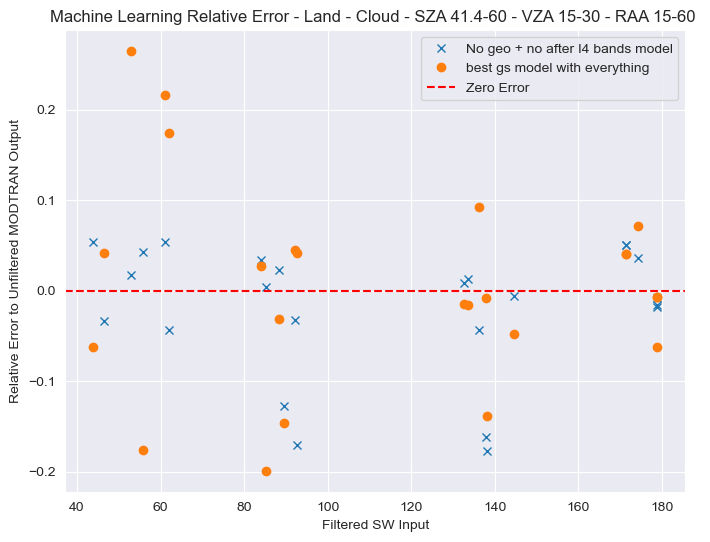

In [58]:
lw_bm_with_bands = test_viirs_bands_refit(all_dataset, v=True, viirs_bands=True, is_sw=False,
                                 selected_viirs_bands=['SZA', 'VZA', 'RAZ','Longwave Filtered Rads (Integrated)',
                                                       'M1', 'M2','M3', 'M4', 'I1', 'M5', 'DNB', 'M6', 'I2', 'M7',
                                                       'M8', 'M9', 'I3', 'M10', 'M11'],  best_params=lw_best, use_groups=True)

lw_bm_with_bands_pe = calculate_pe(matt_test_data, ['SZA', 'VZA', 'RAZ','Longwave Filtered Rads (Integrated)',
                                        'M1', 'M2','M3', 'M4', 'I1', 'M5', 'DNB', 'M6', 'I2', 'M7',
                                        'M8', 'M9', 'I3', 'M10', 'M11'], lw_bm_with_bands['Final_Model'], is_sw=False)

display_pe(sw_input, lw_bm_with_bands_pe, test_refit_pe, "No geo + no after I4 bands model", "best gs model with everything")

Using selected VIIRS bands: ['Longwave Filtered Rads (Integrated)', 'M1', 'M2', 'M3', 'M4', 'I1', 'M5', 'DNB', 'M6', 'I2', 'M7', 'M8', 'M9', 'I3', 'M10', 'M11']
Index(['Longwave Filtered Rads (Integrated)', 'M1', 'M2', 'M3', 'M4', 'I1',
       'M5', 'DNB', 'M6', 'I2', 'M7', 'M8', 'M9', 'I3', 'M10', 'M11'],
      dtype='object')
Train (4955, 16), Val (620, 16), Test (620, 16)
Train scenes: ['Snow' 'Land' 'Deep Convective Cloud' 'Cloudy Ocean' 'Clear Ocean']


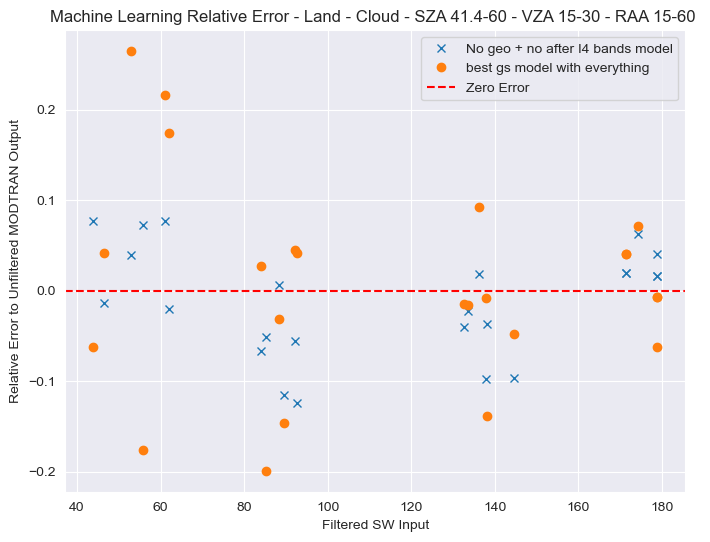

In [57]:
lw_bm_no_bands = test_viirs_bands_refit(all_dataset, v=True, viirs_bands=True, is_sw=False,
                                 selected_viirs_bands=['Longwave Filtered Rads (Integrated)',
                                                       'M1', 'M2','M3', 'M4', 'I1', 'M5', 'DNB', 'M6', 'I2', 'M7',
                                                       'M8', 'M9', 'I3', 'M10', 'M11'],  best_params=lw_best, use_groups=True)

lw_bm_no_bands_pe = calculate_pe(matt_test_data, ['Longwave Filtered Rads (Integrated)',
                                        'M1', 'M2','M3', 'M4', 'I1', 'M5', 'DNB', 'M6', 'I2', 'M7',
                                        'M8', 'M9', 'I3', 'M10', 'M11'], lw_bm_no_bands['Final_Model'], is_sw=False)

display_pe(sw_input, lw_bm_no_bands_pe, test_refit_pe, "No geo + no after I4 bands model", "best gs model with everything")

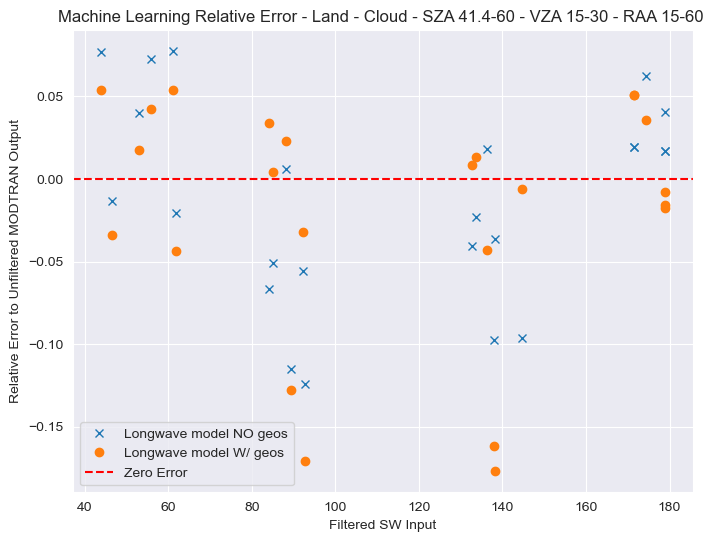

In [59]:
display_pe(sw_input, lw_bm_no_bands_pe, lw_bm_with_bands_pe, "Longwave model NO geos", "Longwave model W/ geos")

In [78]:
compare_global_vs_bin_fit_interactive(
    land_clear,
    scene="Land",
    sza_range=(45,60),
    vza_range=(15,30),
    raz_range=(15,60),
    degree=1,
    ml_model=lw_bm_no_bands["Final_Model"],
    name="LCNA Longwave model",
    ml_features=['Longwave Filtered Rads (Integrated)', 'M1', 'M2', 'M3', 'M4', 'I1', 'M5', 'DNB', 'M6', 'I2', 'M7', 'M8', 'M9', 'I3', 'M10', 'M11'],
    is_sw=False
)


For all Land Clear data:
R² Value: 0.9999198417490353
Root Mean Squared Error: 0.0982127335401307
coefficients: [[0.         1.61151387]], intercept: [-2.87341513]

For binned Land Clear data:
R² Value: 0.9999170829757398
Root Mean Squared Error: 0.06857398078970471
coefficients: [[0.         1.62578257]], intercept: [-3.66869268]

ML Model Metrics:
R² Value: 0.9998106773147155
Root Mean Squared Error: 0.15093675558545824
Mean Absolute Percentage Error: 0.11%
Regression line coefficients: [[0.         0.99736805]], intercept: [0.20629903]


In [82]:
lw_bm_no_bands

{'Val_RMSE': 0.2969643644230279,
 'Val_MAE': 0.14370311100346536,
 'Val_MAPE%': 0.2487432735049431,
 'Val_R2': 0.999685204581403,
 'CV_Fold_RMSEs': array([0.58627415, 0.25232512, 0.29207729, 0.38214369, 0.39309038]),
 'CV_RMSE_mean': 0.38118212863350026,
 'CV_RMSE_std': 0.12917939833361552,
 'Test_RMSE': 0.29134492897448305,
 'Test_MAE': 0.1303522261910587,
 'Test_MAPE%': 0.25049248568130145,
 'Test_R2': 0.9996998625355644,
 'Final_Model': RandomForestRegressor(max_depth=16, max_features=0.5, max_samples=0.9,
                       min_samples_leaf=4, min_samples_split=10,
                       n_estimators=1000),
 'Params_Used': {'max_depth': 16,
  'max_features': 0.5,
  'max_samples': 0.9,
  'min_samples_leaf': 4,
  'min_samples_split': 10,
  'n_estimators': 1000},
 'Train_data': {'X_tr': array([[40.11643078, 21.40751945, 24.15756924, ...,  0.81047811,
           0.81047811,  0.26125786],
         [42.26882459, 21.74881366, 24.59310723, ...,  0.45954763,
           0.45954763,  0.18

In [86]:
unseen_lw = lw_bm_no_bands["Test_data"]
X_unseen_lw = unseen_lw["X_test"]
y_unseen_lw = unseen_lw["y_test"]
meta_unseen = unseen_lw["meta_test"]
print(np.shape(X_unseen_lw))
test_features_lw = pd.DataFrame(X_unseen_lw, columns=["SZA", "VZA", "RAZ",
       'Longwave Filtered Rads (Integrated)', 'M1', 'M2', 'M3', 'M4', 'I1',
       'M5', 'DNB', 'M6', 'I2', 'M7', 'M8', 'M9', 'I3', 'M10', 'M11'])
test_target_lw = pd.Series(y_unseen_lw, name="Longwave Unfiltered Rads (Integrated)")
full_test_df_lw = pd.concat([test_features_lw, test_target_lw], axis=1)


compare_global_vs_bin_fit_interactive(
    full_test_df_lw,
    scene="Unseen Data",
    sza_range=(45,60),
    vza_range=(15,30),
    raz_range=(15,60),
    degree=1,
    ml_model=lw_bm_no_bands["Final_Model"],
    name="Unseen Dataset, no Angles",
    ml_features=['Longwave Filtered Rads (Integrated)', 'M1', 'M2', 'M3', 'M4', 'I1', 'M5', 'DNB', 'M6', 'I2', 'M7', 'M8', 'M9', 'I3', 'M10', 'M11'], is_sw=False
)

(620, 16)


ValueError: Shape of passed values is (620, 16), indices imply (620, 19)